# Проект. Исследование стартапов

## Введение

Данный проект выполняется для финансовой компании, которая планирует выйти на рынок венчурных инвестиций с целью покупки и развития перспективных стартапов. Чтобы минимизировать риски и построить эффективную стратегию, компании необходимо глубоко понять закономерности и динамику финансирования стартапов, основываясь на исторических данных. 

Целью проекта является комплексный анализ данных о стартапах: от предобработки и изучения структуры инвестиций до оценки возвратов по различным типам финансирования. Ключевой задачей является выявление наиболее перспективных направлений и форм для инвестиций. Итогом работы станут конкретные рекомендации о том, в какие отрасли и каким образом было бы целесообразно инвестировать, с перспективой на 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

Сначала импортируем нужные для работы библиотеки

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

# Загружаем библиотеку missingno
!pip install missingno

# Визуализируем пропуски и корреляцию для наглядности
import missingno as msno                                                                               

Загружаем данные. Исходные датасеты являются конфиденциальной информацией и не включены в публичный репозиторий. 

In [2]:
try:
    df_investments = pd.read_csv("https://...cb_investments.zip", sep=';', low_memory=False)
except:
    print("Проверьте путь к файлу")

In [3]:
try:
    df_returns = pd.read_csv('https://....cb_returns.csv')
except:
    print("Проверьте путь к файлу")

Выведите информацию, которая необходима для принятия решений о предобработке.

Посмотрим на датасет с информацией об инвестициях

In [4]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Построим визуализацию пропущенных данных в df_investments с помощью библиотеки missingno (для наглядности).

<AxesSubplot:>

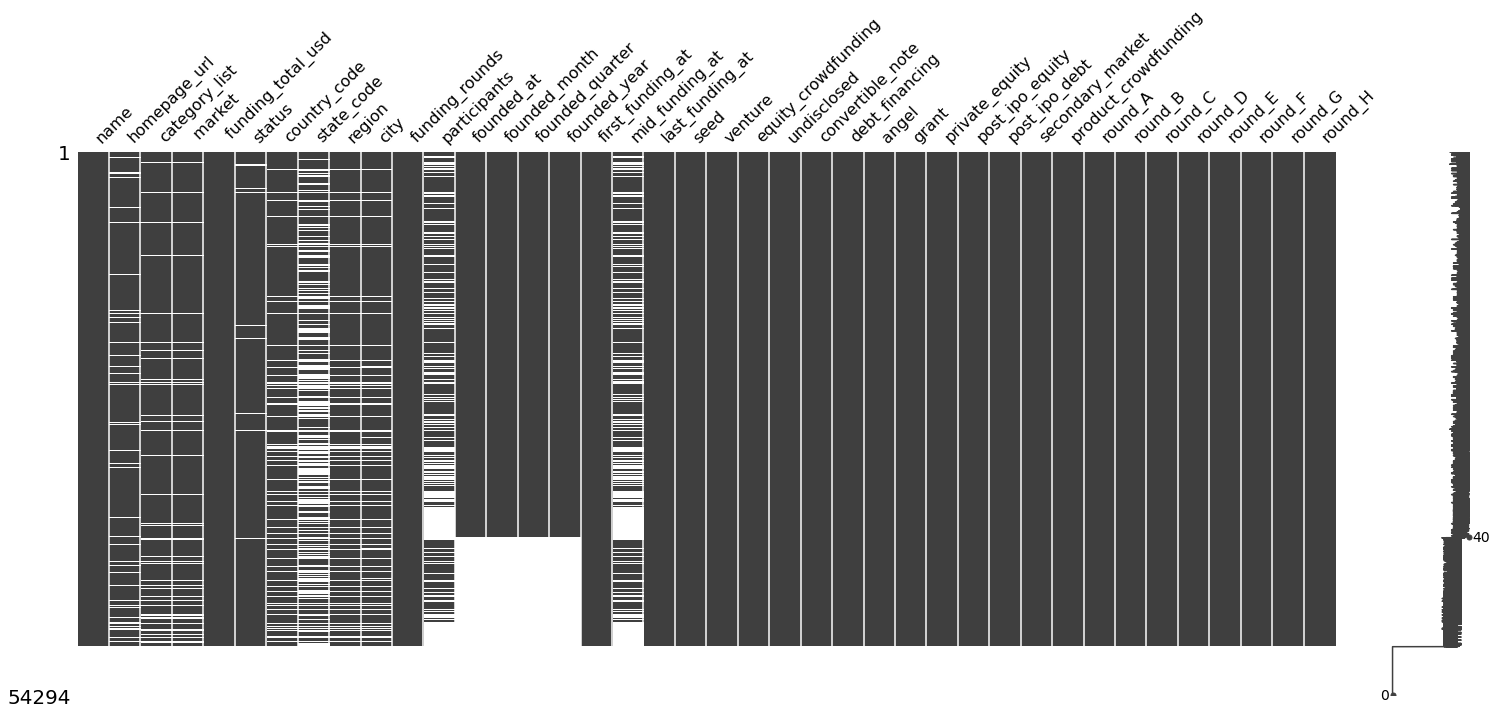

In [5]:
msno.matrix(df_investments)

Первое, что мы видим: в данных достаточно много пропусков, но это типично для реальных датасетов.

Изначально в датасете 54,294 записи. Все столбцы с seed по round_H имеют одинаковое количество ненулевых значений (49438).

Много пропусков в столбцах:
* География: state_code (код штата) пропущена почти наполовину (30k из 54k). Это важно, если анализ будет по регионам.
* Дата основания: founded_at и связанные с ней столбцы пропущены примерно для 15000 компаний. Это может усложнить анализ по возрасту стартапов.
* Участники раундов: в participants очень много пропусков (около 30 тысяч).

Пропуски в name, homepage_url, category_list, market (около 4.8-5k пропусков в каждом) - это очень нехорошо, так как это важные идентифицирующие поля. Скорее все, заменим эти пропуски заглушками, подходящими по смыслу.

Столбец mid_funding_at имеет всего 30288 значений. Это сильно меньше, чем у first/last_funding_at. Этот столбец требует отдельного внимания, как и указано в задании.

В типах данных есть критически важное несоответствие: funding_total_usd имеет тип object. Это абсолютно неправильно для столбца с денежными суммами. Он должен быть числовым. Скорее всего, в данных есть нечисловые символы (например, пробелы, запятые как разделители тысяч, или строки вроде "-"). Это обязательный, важнейший пункт для предобработки.
Тут же отметим, что float не идеален для финансов из-за ошибок округления. Если бы это был финансовый отчет, где очень важна точность, мы бы использовали для финансовых столбцов тип decimal, но в данном учебном аналитическом проекте считаю адекватным привести все финансовые столбцы в целочисленный тип (посли обработки пропусков).

Столбец founded_year имеет тип float64. Год логичнее хранить как целое число (int), но из-за пропусков pandas использует float. После обработки пропусков можно будет попробовать привести к Int64, но, в принципе, можно оставить и так, это не серьезная проблема.

Даты (founded_at, first_funding_at и др.) имеют тип object. Это тоже нужно исправить, преобразовав их в тип datetime64 для корректной работы с временными рядами.

Еще видим странность в названиях столбцов: столбцы market и funding_total_usd в выводе имеют по лишнему пробелу в начале (market, funding_total_usd). Это опечатка, которую нужно исправить, чтобы не путаться при обращении к столбцам.

In [6]:
df_investments.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,"87,00,000",operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,NaN,"60,00,000",operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,"35,00,000",acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


После просмотра первых строк данных можно сделать такие выводы:
Есть проблема с форматом чисел в funding_total_usd: значения выглядят как 9,00,00,000. Это индийская система записи чисел. При преобразовании этого столбца в число нужно будет удалить все запятые. Простое удаление запятых приведёт к корректным числам.

Вот такое еще наблюдение: в данных присутствуют университеты (Harvard, University of New Brunswick) и крупные корпорации (DuPont). Это не типичные стартапы. Венчурные фонды обычно инвестируют в молодые, быстрорастущие компании, а не в учреждения с вековой историей.
Возможно, это данные о дочерних проектах этих учреждений. В реальных условиях стоило бы уточнить, как относиться к этим данным, но в учебном проекте оставитм эти строки без изменений.

Так же выявилась проблема с category_list: значения начинаются и/или заканчиваются символом | (например, |Education|). Это некрасиво и может мешать анализу. Нужно очистить эти значения, убрав лишние символы-разделители.

Еще бросаются в глаза пропуски в category_list и market: у строки 1 (University of New Brunswick) в этих полях стоит NaN. Это подтверждает необходимость обработки пропусков для категориальных полей.

Теперь посмотрим названия столбцов: тут тоже есть над чем поработать. Приведём их к snake_case и уберем пробелы перед market и funding_total_usd.

Теперь посмотрим информацию по возвратам инвесторам, датасет df_returns

In [7]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Таблица очень небольшая, всего 15 строк. Это временной ряд, где каждая строка, скорее всего, соответствует одному году.

В таблице нет ни одного пропуска. Это отличная новость, обработка пропусков не потребуется.

Все типы данных выглядят правильными: столбец year имеет тип int64, что логично для года., а вот столбцы с финансовыми данными (seed, venture и т.д.) имеют тип float64. Это финансовые суммы, выраженные в миллионах долларов (это указано в описании данных). Имеет смысл перевести в целочисленный тип, как мы предположили выше про финансовые столбцы.

Сейчас столбец year - это временной ряд, и его логично сделать индексом для удобства анализа динамики, как и рекомендовано в задании.

Важный момент: столбцы с финансированием (seed, venture и др.) названы так же, как в таблице df_investments, но несут другую смысловую нагрузку (возвраты, а не вложения). Необходимо переименовать их перед любым объединением таблиц, чтобы избежать путаницы. Добавим к названию столбца суффикс вида столбец_returns, так название останется интуитивно понятным.

Обязательно нужно запомнить, что данные о возвратах представлены в миллионах долларов, в то время как в df_investments суммы в долларах. Это важно  при визуализации и интерпретации графиков: эти два датасета визуально сравнивать по абсолютным значениям нельзя, нужны преобразования.

Еще наблюдения: 15 строк предполагают, что данные охватывают период с 2000 по 2014 год. Необходимо уточнить минимальный и максимальный год в данных, чтобы понять, за какой период у нас есть информация о возвратах (верно ли предположение о 2000-2014).

Датасет df_returns небольшой, посмотрим его весь:

In [8]:
df_returns

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


Да, теперь предположение подтвердилось, 15 строк - это годы 2000-2014 (15 лет). 

Суммы в миллионах долларов (как указано в описании), все числовые значения с 2 знаками после запятой. Думаю, имеет смысл рассмотреть конвертацию в целые числа (миллионы долларов). Это решит проблему с типами данных и визуализациями относительно df_investments.

Привлекает внимание:
* equity_crowdfunding, product_crowdfunding содержат почти нулевые значения до 2010+
* grant полностью нулевой столбец, 0.0 все годы. Это логично, поскольку гранты не предполагают возврата средств. 
* post_ipo_debt — появляется только с 2011 года  

Нет данных по некоторым типам, которые есть в таблице investments.

Данные качественные, показывают четкие тренды роста венчурного рынка.

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Промежуточный вывод из знакомства с данными

В результате первичного анализа данных выявлена следующая картина. У нас есть два датасета: основной массив информации об инвестициях содержит 54294 записи, из которых после базовой очистки останется примерно 49438 значимых записей, и небольшой датасет о возвратах инвестиций, охватывающий 15-летний период с 2000 по 2014 год.

Среди критически важных проблем необходимо отметить некорректный формат хранения финансовых данных. Ключевой столбец funding_total_usd имеет текстовый тип из-за использования индийского формата записи чисел с запятыми. Также выявлена смысловая проблема: одинаковые названия финансовых столбцов в двух таблицах означают принципиально разные вещи, вложения и возвраты средств. Серьёзной проблемой является большое количество пропусков в важнейших полях: около 45% данных по географическому расположению, 28% по датам основания компаний и 44% по информации об участниках инвестиционных раундов.

Наблюдаются системные проблемы с типами данных: все поля с датами хранятся в текстовом формате вместо специализированного datetime, год основания представлен как число с плавающей точкой вместо целого, а финансовые показатели требуют конверсии в целочисленные типы.

Среди особенностей данных стоит отметить присутствие университетов и крупных корпораций, что не совсем типично для венчурных инвестиций (принимаем решение оставить это без изменений в формате учебного проекта), а также наличие лишних разделителей в категориях компаний. В данных о возвратах полностью отсутствуют значения по грантам, что требует отдельного изучения. Дополнительной сложностью является разный масштаб денежных сумм в таблицах (доллары против миллионов долларов).

Таким образом, приоритетами предобработки становятся: исправление форматов числовых данных, переименование конфликтующих столбцов, обработка пропусков и системное преобразование типов данных для обеспечения корректности последующего анализа.

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

В названиях столбцов market и funding_total_usd есть лишние пробелы в начале, которые мешают корректному обращению к данным. Уберем пробелы из названий столбцов:

In [9]:
# Убираем лишние пробелы в начале и конце названий всех столбцов в df_investments
df_investments.columns = df_investments.columns.str.strip()

Большинство названий столбцов уже в snake_case, но для единообразия и исправления возможных неочевидных проблем приведём все к нижнему регистру и заменим пробелы на подчёркивания.

In [10]:
# Приводим все названия столбцов к нижнему регистру и заменяем пробелы на '_'
df_investments.columns = df_investments.columns.str.lower().str.replace(' ', '_')

Проверим, как получилось:

In [11]:
df_investments.columns.tolist()

['name',
 'homepage_url',
 'category_list',
 'market',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'participants',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'mid_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_a',
 'round_b',
 'round_c',
 'round_d',
 'round_e',
 'round_f',
 'round_g',
 'round_h']

Все выглядит хорошо. Теперь перейдем к работе с названиями столбцов в таблице в возвратами. Это критически важный шаг перед объединением таблиц, чтобы различать вложенные и возвращённые средства. Заменяем названия столбцов в таблице с возвратами, добавляя суффикс _return

In [12]:
#смотрим, как выглядят столбцы сейчас
df_returns.columns.tolist()

['year',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding']

In [13]:
# Создаем словарь, где для каждого столбца будет новое имя
rename_dict = {}
for col in df_returns.columns:
    if col == 'year':
        rename_dict[col] = col  # 'year' остается 'year'
    else:
        rename_dict[col] = f"{col}_return"  # к остальным добавляем '_return'

df_returns_renamed = df_returns.rename(columns=rename_dict)

Проверяем результат переименования

In [14]:
df_returns_renamed.columns.tolist()

['year',
 'seed_return',
 'venture_return',
 'equity_crowdfunding_return',
 'undisclosed_return',
 'convertible_note_return',
 'debt_financing_return',
 'angel_return',
 'grant_return',
 'private_equity_return',
 'post_ipo_equity_return',
 'post_ipo_debt_return',
 'secondary_market_return',
 'product_crowdfunding_return']

Все, как мы и хотели. Теперь, когда мы уверены в результате, можно перезаписать датафрейм

In [15]:
# Перезаписываем исходный датафрейм
df_returns = df_returns_renamed

In [16]:
df_returns.columns.tolist()

['year',
 'seed_return',
 'venture_return',
 'equity_crowdfunding_return',
 'undisclosed_return',
 'convertible_note_return',
 'debt_financing_return',
 'angel_return',
 'grant_return',
 'private_equity_return',
 'post_ipo_equity_return',
 'post_ipo_debt_return',
 'secondary_market_return',
 'product_crowdfunding_return']

Теперь у нас чистые, однозначные названия столбцов, готовые для дальнейшего анализа.

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

Сначала посмотрим на текущие значения, чтобы понять структуру.

In [17]:
# Посмотрим на несколько значений до преобразования
df_investments['funding_total_usd'].head(10)

0     9,00,00,000 
1       20,00,000 
2       90,00,000 
3       77,00,000 
4        5,40,000 
5     1,90,00,000 
6     1,20,00,000 
7       87,00,000 
8       60,00,000 
9       35,00,000 
Name: funding_total_usd, dtype: object

In [18]:
# Убираем все запятые из значений в столбце funding_total_usd
df_investments['funding_total_usd'] = df_investments['funding_total_usd'].str.replace(',', '')

# Проверяем результат
df_investments['funding_total_usd'].head(10)

0     90000000 
1      2000000 
2      9000000 
3      7700000 
4       540000 
5     19000000 
6     12000000 
7      8700000 
8      6000000 
9      3500000 
Name: funding_total_usd, dtype: object

Преобразуем строковые значения в числовые. Будем использовать pd.to_numeric с обработкой ошибок, так неконвертируемые значения станут NaN.

In [19]:
# Преобразуем строковые значения в целочисленный тип
df_investments['funding_total_usd'] = pd.to_numeric(df_investments['funding_total_usd'], errors='coerce')

# Проверяем тип данных и результат преобразования
df_investments['funding_total_usd'].head(10)

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
5    19000000.0
6    12000000.0
7     8700000.0
8     6000000.0
9     3500000.0
Name: funding_total_usd, dtype: float64

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

В таблице investments есть несколько столбцов с датами, которые сейчас хранятся как object. Преобразуем их в правильный формат datetime.

In [20]:
# Список столбцов с датами для преобразования
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Преобразуем каждый столбец в формат datetime
for col in date_columns:
    df_investments[col] = pd.to_datetime(df_investments[col], errors='coerce')

# Проверяем результат
df_investments[date_columns].dtypes

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

Мне еще не очень понятно, почему месяц и квартал основания в типе object, посмотрим, почему:

In [21]:
# Смотрим первые строки для столбцов с месяцем, кварталом и годом основания так, чтобы сделать выводы о форматах
df_investments[['founded_month', 'founded_quarter', 'founded_year']].head(100)

,founded_month,founded_quarter,founded_year
0,NaN,NaN,1636.0
1,NaN,NaN,1785.0
2,NaN,NaN,1802.0
3,NaN,NaN,1817.0
4,NaN,NaN,1826.0
...,...,...,...
95,1914-01,1914-Q1,1914.0
96,1914-01,1914-Q1,1914.0
97,1917-01,1917-Q1,1917.0
98,1918-01,1918-Q1,1918.0


Эти столбцы хранят строки в формате "YYYY-MM" и "YYYY-QN". Их можно оставить как есть, либо преобразовать в специальные периодические типы, но для данного проекта в этом нет острой необходимости - в явном виде эти столбцы не упоминаются и работать с ними не нужно будет.

В итоге наш датасет с инвестициями выглядит так после приведения типов данных

In [22]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

Сделаем столбец year индексом для датасета с возвратами. Это очень удобно для временного анализа.

In [23]:
# Проверяем текущий индекс и данные
print("Индекс df_returns до преобразования:")
print(df_returns.index)

# Устанавливаем столбец year в качестве индекса
df_returns = df_returns.set_index('year')

# Проверяем результат
print("\nИндекс после преобразования:")
print(df_returns.index)

Индекс df_returns до преобразования:
RangeIndex(start=0, stop=15, step=1)

Индекс после преобразования:
Int64Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
            2011, 2012, 2013, 2014],
           dtype='int64', name='year')


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

Сначала посмотрим, какие у нас есть текстовые столбцы и сколько в них пропусков:

In [24]:
# Выделяем столбцы типа object
text_columns = df_investments.select_dtypes(include=['object']).columns
text_columns.tolist()


['name',
 'homepage_url',
 'category_list',
 'market',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'founded_month',
 'founded_quarter']

У нас 11 текстовых столбцов. Посмотрим пропуски в них

In [25]:
# Пропуски в текстовых столбцах
for col in text_columns:
    null_count = df_investments[col].isna().sum()
    total_count = len(df_investments)
    print(f"{col}: {null_count}/{total_count} ({null_count/total_count*100:.1f}%) пропусков")

name: 4857/54294 (8.9%) пропусков
homepage_url: 8305/54294 (15.3%) пропусков
category_list: 8817/54294 (16.2%) пропусков
market: 8817/54294 (16.2%) пропусков
status: 6170/54294 (11.4%) пропусков
country_code: 10129/54294 (18.7%) пропусков
state_code: 24133/54294 (44.4%) пропусков
region: 10129/54294 (18.7%) пропусков
city: 10972/54294 (20.2%) пропусков
founded_month: 15812/54294 (29.1%) пропусков
founded_quarter: 15812/54294 (29.1%) пропусков


Нормализуем текстовые данные. Сначала очистим все текстовые столбцы от лишних пробелов в начале и конце строк:

In [26]:
# Очищаем каждый текстовый столбец от пробелов
for column in text_columns:
    df_investments[column] = df_investments[column].str.strip()

Теперь приведем все текстовые столбцы к верхнему регистру для единообразия данных:

In [27]:
# Приводим все текстовые значения к верхнему регистру
for column in text_columns:
    df_investments[column] = df_investments[column].str.upper()

Теперь разберемся со столбцом category_list. В нем есть лишние символы "|" в начале и конце, уберем их:

In [28]:
# Убираем лишние | в начале и конце строки
df_investments['category_list'] = df_investments['category_list'].str.strip('|')
df_investments['category_list'].head(10)

0                                            EDUCATION
1                                                  NaN
2    BUSINESS SERVICES|AGRICULTURE|AUTOMOTIVE|INVES...
3                                            EDUCATION
4                                            EDUCATION
5                                                  NaN
6                                            EDUCATION
7                                            EDUCATION
8                                                  NaN
9                                         SOCIAL MEDIA
Name: category_list, dtype: object

    Выглядит нормально. Тепрь заменим проуски на UNKNOWN CATEGORY:

In [29]:
# Заполняем пропуски в category_list
df_investments['category_list'] = df_investments['category_list'].fillna('UNKNOWN CATEGORY')
df_investments['category_list'].head(10)

0                                            EDUCATION
1                                     UNKNOWN CATEGORY
2    BUSINESS SERVICES|AGRICULTURE|AUTOMOTIVE|INVES...
3                                            EDUCATION
4                                            EDUCATION
5                                     UNKNOWN CATEGORY
6                                            EDUCATION
7                                            EDUCATION
8                                     UNKNOWN CATEGORY
9                                         SOCIAL MEDIA
Name: category_list, dtype: object

Теперь обработаем пропуски в других текстовых столбцах. Заполним их понятными заглушками:

In [30]:
# Создадим словарь для заполнения пропусков
fillna_dict = {
    'name': 'UNKNOWN COMPANY',
    'homepage_url': 'NO WEBSITE',
    'market': 'UNKNOWN MARKET',
    'status': 'UNKNOWN STATUS',
    'country_code': 'UNKNOWN COUNTRY',
    'state_code': 'UNKNOWN STATE',
    'region': 'UNKNOWN REGION',
    'city': 'UNKNOWN CITY'
}

# Заполняем пропуски
for col, fill_value in fillna_dict.items():
    if col in df_investments.columns:
        df_investments[col].isna().sum()
        df_investments[col] = df_investments[col].fillna(fill_value)

In [31]:
# Проверяем результат
df_investments[text_columns].isna().sum()

name                   0
homepage_url           0
category_list          0
market                 0
status                 0
country_code           0
state_code             0
region                 0
city                   0
founded_month      15812
founded_quarter    15812
dtype: int64

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. Избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

Удалим полные дубликаты строк, чтобы избавиться от повторяющихся записей:

In [32]:
# Удаляем полные дубликаты
before_total_drop_count = len(df_investments)
df_investments = df_investments.drop_duplicates()
after_total_drop_count = len(df_investments)

In [33]:
#Сколько дубликатов было удалено
deleted_count = before_total_drop_count - after_total_drop_count
deleted_count

4855

Проверим частичные дубликаты сначала по названию компании.

In [34]:
# Проверим дубликаты по названию компании (самый очевидный признак)
name_duplicates = df_investments[df_investments.duplicated('name', keep=False)]
len(name_duplicates)

202

Нашлось 140 дубликатов по названию комании, но это могут быть разные стартапы. Проверим еще по комбинации названия компании, веб сайту компании и рынку (market), это наиболее точный способ найти настоящие дубликаты.

In [35]:
# Проверим дубликаты по комбинации названия, сайта и рынка
strict_duplicates = df_investments[df_investments.duplicated(['name', 'homepage_url', 'market'], keep=False)]
len(strict_duplicates)

10

Посмотрим, как выглядят эти строки с дубликатами:

In [36]:
# Найдем и выведем полные строки с дубликатами
duplicate_mask = df_investments.duplicated(['name', 'homepage_url', 'market'], keep=False)
duplicates_df = df_investments[duplicate_mask]
duplicates_df

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
11350,KICKSERV,HTTP://WWW.KICKSERV.COM,SAAS|SERVICES|SOFTWARE,SAAS,1100000.0,OPERATING,USA,CA,SF BAY AREA,MILL VALLEY,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14111,BASEKIT,HTTP://WWW.BASEKIT.COM,WEB DESIGN|INTERNET|CURATED WEB,CURATED WEB,15918631.0,OPERATING,GBR,UNKNOWN STATE,LONDON,LONDON,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15062,BASEKIT,HTTP://WWW.BASEKIT.COM,CURATED WEB,CURATED WEB,7000000.0,OPERATING,GBR,UNKNOWN STATE,LONDON,LONDON,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21434,INMARKET,HTTP://WWW.INMARKET.COM,APPS|HARDWARE|SHOPPING|RETAIL|ONLINE RESERVATI...,MOBILE,1000000.0,OPERATING,USA,CA,LOS ANGELES,LOS ANGELES,...,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21444,INMARKET,HTTP://WWW.INMARKET.COM,MOBILE SHOPPING|ADVERTISING|RETAIL|SHOPPING|MO...,MOBILE,1000000.0,OPERATING,USA,CA,LOS ANGELES,LOS ANGELES,...,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26870,KICKSERV,HTTP://WWW.KICKSERV.COM,SMALL AND MEDIUM BUSINESSES|SAAS,SAAS,600000.0,OPERATING,USA,CA,SF BAY AREA,MILL VALLEY,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42849,LIGHTEX LTD.,NO WEBSITE,UNKNOWN CATEGORY,UNKNOWN MARKET,500000.0,OPERATING,UNKNOWN COUNTRY,UNKNOWN STATE,UNKNOWN REGION,UNKNOWN CITY,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43186,LIGHTEX LTD.,NO WEBSITE,UNKNOWN CATEGORY,UNKNOWN MARKET,NaN,OPERATING,UNKNOWN COUNTRY,UNKNOWN STATE,UNKNOWN REGION,UNKNOWN CITY,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44111,GAIN FITNESS,HTTP://GAINFITNESS.COM,FITNESS|HEALTH AND WELLNESS,HEALTH AND WELLNESS,2790000.0,OPERATING,USA,CA,SF BAY AREA,SAN FRANCISCO,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44112,GAIN FITNESS,HTTP://GAINFITNESS.COM,HEALTH AND WELLNESS,HEALTH AND WELLNESS,2790000.0,OPERATING,USA,CA,SF BAY AREA,SAN FRANCISCO,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


* строки с компанией KICKSERV очевидно разные стартапы, оставляем
* строки с компанией BASEKIT тоже разные, оставляем
* строки с компанией LIGHTEX LTD. явно дубликаты, удаляем строку 43186, где NaN в funding_total_usd
* строки с компанией INMARKEТ различаются только категорией, остальное одинаковое, убираем первую (строка 21434)
* строки с компанией GAIN FITNESS различаются только категорией, это явно один и тот же стартап, убираем первую (строка 44111)

In [37]:
# Удаляем строки с номерами 21434 и 44111
df_investments = df_investments.drop([21434, 44111, 43186])

In [38]:
# Процент удаленных дубликатов
rounded_percentage = round(((deleted_count+3)/ before_total_drop_count) * 100, 2)
rounded_percentage

8.95

Обработаем пропуски в funding_total_usd и избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

Сначала удалим строки с пропусками в funding_total_usd:

In [39]:
# Удаляем строки с пропусками в funding_total_usd
before_null_drop_count = len(df_investments)
df_investments = df_investments.dropna(subset=['funding_total_usd'])
after_null_drop_count = len(df_investments)

Теперь удалим строки, где funding_total_usd равен 0, так как они также не несут информации о финансировании:

In [40]:
# Удаляем строки с нулевым финансированием
before_zero_drop_count = len(df_investments)
df_investments = df_investments[df_investments['funding_total_usd'] != 0]
after_zero_drop_count = len(df_investments)

Сколько всего было удалено строк из funding_total_usd:

In [41]:
# Количество удаленных строк (после удаления пропусков и 0)
deleted_null_count = before_null_drop_count - after_null_drop_count
deleted_zero_count = before_zero_drop_count - after_zero_drop_count
total_deleted_count = deleted_null_count + deleted_zero_count
total_deleted_count

8531

In [42]:
# Процент удаленных строк
round((total_deleted_count / before_null_drop_count) * 100, 2)

17.26

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

Заполним пропуски в mid_funding_at, вычислив среднюю дату между first_funding_at и last_funding_at

In [43]:
# Подсчитываем количество пропусков в столбце mid_funding_at до заполнения
before_null = df_investments['mid_funding_at'].isna().sum()

# Заполняем пропуски в mid_funding_at средней датой между first_funding_at и last_funding_at
df_investments['mid_funding_at'] = df_investments['mid_funding_at'].fillna(
    df_investments['first_funding_at'] + (df_investments['last_funding_at'] - df_investments['first_funding_at']) / 2
)

# Подсчитываем количество пропусков в столбце mid_funding_at после заполнения
after_null = df_investments['mid_funding_at'].isna().sum()

In [44]:
# Выводим количество заполненных пропусков (разница между количеством до и после)
filled_null = before_null - after_null
filled_null

13675

In [45]:
# Оцениваем оставшиеся пропуски
remaining_nulls = df_investments['mid_funding_at'].isna().sum()
remaining_nulls 

1

У нас остался всего один пропуск в mid_funding_at. Удалим эту строку, так как один пропуск не повлияет на статистику, но может вызвать ошибки в анализе:

In [46]:
# Удаляем строку с оставшимся пропуском в mid_funding_at
before_count = len(df_investments)
df_investments = df_investments.dropna(subset=['mid_funding_at'])

Проверим теперь пропуски в mid_funding_at:

In [47]:
# Проверим теперь пропуски в mid_funding_at
remaining_nulls = df_investments['mid_funding_at'].isna().sum()
remaining_nulls

0

Удалим строку с пропуском в столбце first_funding_at:

In [48]:
# Удаляем строку с пропуском
df_investments = df_investments.dropna(subset=['first_funding_at'])

# Проверяем результат
null_count_after = df_investments['first_funding_at'].isna().sum()
null_count_after

0

С пропусками закончили. Преобразуем финансовые столбцы из float64 в целочисленный тип для точности расчетов и экономии памяти.

In [49]:
# Список финансовых столбцов для преобразования в целочисленный тип
financial_columns = [
    'funding_total_usd', 'seed', 'venture', 'equity_crowdfunding', 
    'undisclosed', 'convertible_note', 'debt_financing', 'angel', 
    'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
    'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'
]

# Преобразуем каждый финансовый столбец в целочисленный тип
for col in financial_columns:
    if col in df_investments.columns:
        df_investments[col] = df_investments[col].astype('int64')

In [50]:
# Преобразуем funding_rounds в целочисленный тип
df_investments['funding_rounds'] = df_investments['funding_rounds'].astype('int64')

Проверим, как получилось:

In [51]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40903 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40903 non-null  object        
 1   homepage_url          40903 non-null  object        
 2   category_list         40903 non-null  object        
 3   market                40903 non-null  object        
 4   funding_total_usd     40903 non-null  int64         
 5   status                40903 non-null  object        
 6   country_code          40903 non-null  object        
 7   state_code            40903 non-null  object        
 8   region                40903 non-null  object        
 9   city                  40903 non-null  object        
 10  funding_rounds        40903 non-null  int64         
 11  participants          27328 non-null  float64       
 12  founded_at            32197 non-null  datetime64[ns]
 13  founded_month   

Вспоминаем, что данные о возвратах представлены в миллионах долларов, в то время как в df_investments суммы в долларах. Преобразуем данные о возвратах из миллионов долларов в доллары, умножив на 1,000,000, и затем переведем в целочисленный тип для согласованности с данными об инвестициях.

In [52]:
# Преобразуем все столбцы с возвратами из миллионов долларов в доллары
return_columns = [col for col in df_returns.columns if col.endswith('_return')]

for col in return_columns:
    df_returns[col] = (df_returns[col] * 1_000_000).astype('int64')

In [53]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   seed_return                  15 non-null     int64
 1   venture_return               15 non-null     int64
 2   equity_crowdfunding_return   15 non-null     int64
 3   undisclosed_return           15 non-null     int64
 4   convertible_note_return      15 non-null     int64
 5   debt_financing_return        15 non-null     int64
 6   angel_return                 15 non-null     int64
 7   grant_return                 15 non-null     int64
 8   private_equity_return        15 non-null     int64
 9   post_ipo_equity_return       15 non-null     int64
 10  post_ipo_debt_return         15 non-null     int64
 11  secondary_market_return      15 non-null     int64
 12  product_crowdfunding_return  15 non-null     int64
dtypes: int64(13)
memory usage: 1.6 KB


In [54]:
df_returns

,seed_return,venture_return,equity_crowdfunding_return,undisclosed_return,convertible_note_return,debt_financing_return,angel_return,grant_return,private_equity_return,post_ipo_equity_return,post_ipo_debt_return,secondary_market_return,product_crowdfunding_return
year,,,,,,,,,,,,,
2000,16700000,55400000,0,78210000,0,8660000,6430000,0,0,940000,0,200000,0
2001,2880000,23490000,0,21500000,10000,4490000,1180000,0,0,460000,0,460000,0
2002,6590000,209420000,0,25770000,20000,3420000,3410000,0,1510000,340000,0,60000,0
2003,7740000,233860000,0,9400000,10000,1090000,3410000,0,1620000,2110000,0,80000,0
2004,9930000,555900000,0,33189999,10000,13550000,9180000,0,2190000,3380000,0,550000,0
2005,26600000,2628920000,0,9510000,20000,35090000,31060000,0,2400000,3510000,0,50000,0
2006,61810000,3100180000,190000,46740000,1780000,113210000,47750000,0,16670000,20580000,0,120000,0
2007,70410000,3585370000,10000,55370000,3220000,125680000,164510000,0,88810000,24360000,0,570000,0
2008,89720000,2717020000,30000,41020000,1710000,397540000,102830000,0,130380000,84280000,0,470000,0


Считаю, что предобработка на этом завершена.

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

Посмотрим наш датасет после предобработки:

In [55]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40903 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40903 non-null  object        
 1   homepage_url          40903 non-null  object        
 2   category_list         40903 non-null  object        
 3   market                40903 non-null  object        
 4   funding_total_usd     40903 non-null  int64         
 5   status                40903 non-null  object        
 6   country_code          40903 non-null  object        
 7   state_code            40903 non-null  object        
 8   region                40903 non-null  object        
 9   city                  40903 non-null  object        
 10  funding_rounds        40903 non-null  int64         
 11  participants          27328 non-null  float64       
 12  founded_at            32197 non-null  datetime64[ns]
 13  founded_month   

Оценим полноту данных и процент отброшенных записей после предобработки:

Посмотрим initial_count, это исходное количество записей в датасете:

In [57]:
initial_count = len(pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False))
initial_count

54294

Теперь посмотрим final_count, это количество записей после всей предобработки:

In [58]:
final_count = len(df_investments)
final_count

40903

In [59]:
discarded_count = initial_count - final_count
discarded_percent = (discarded_count / initial_count) * 100

print(f"Начальное количество записей: {initial_count}")
print(f"Финальное количество записей: {final_count}")
print(f"Отброшено записей: {discarded_count} ({discarded_percent:.1f}%)")

Начальное количество записей: 54294
Финальное количество записей: 40903
Отброшено записей: 13391 (24.7%)


Проанализируем оставшиеся пропуски в ключевых столбцах для оценки полноты данных:

In [60]:
# Анализ пропусков в ключевых столбцах после предобработки
key_columns = ['founded_at', 'first_funding_at', 'participants', 'founded_year']
for col in key_columns:
    null_count = df_investments[col].isna().sum()
    total_count = len(df_investments)
    percent = (null_count / total_count) * 100
    print(f"{col}: {null_count}/{total_count} ({percent:.1f}%)")

founded_at: 8706/40903 (21.3%)
first_funding_at: 0/40903 (0.0%)
participants: 13575/40903 (33.2%)
founded_year: 8705/40903 (21.3%)


Оценим достаточность данных для решения задач проекта:

In [61]:
# Проверяем наличие данных для основных задач проекта

print(f"Компании с информацией о финансировании: {final_count} (100%)")
print(f"Компании с датами финансирования: {df_investments['first_funding_at'].notna().sum()} ({(df_investments['first_funding_at'].notna().sum()/final_count)*100:.1f}%)")
print(f"Компании с информацией о раундах: {final_count} (100%)")
print(f"Компании с категориями рынка: {final_count} (100%)")

Компании с информацией о финансировании: 40903 (100%)
Компании с датами финансирования: 40903 (100.0%)
Компании с информацией о раундах: 40903 (100%)
Компании с категориями рынка: 40903 (100%)


Обновим визуализацию пропущенных данных в df_investments после предобработки с помощью библиотеки missingno (для наглядности).

<AxesSubplot:>

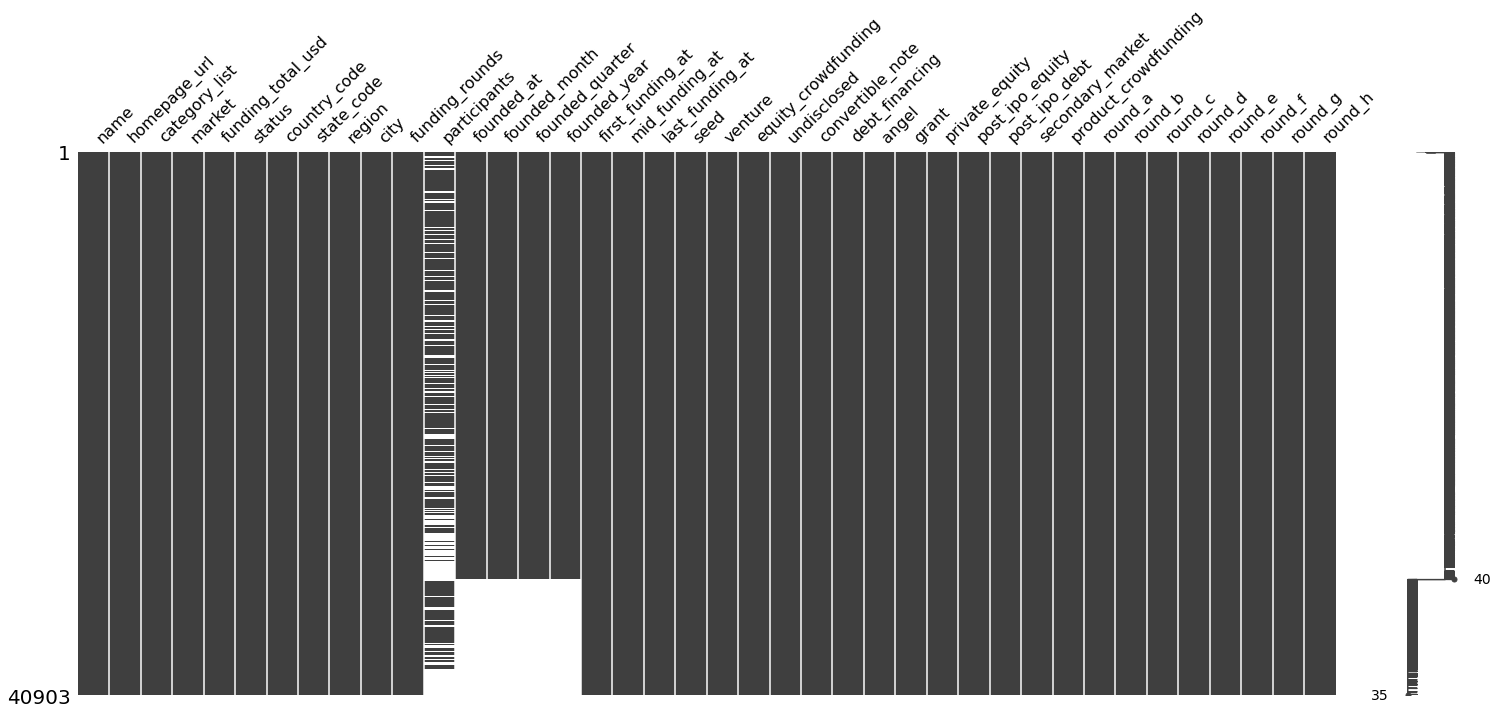

In [62]:
msno.matrix(df_investments)

Предварительный вывод по итогам предобработки:

В результате предобработки данных мы подготовили качественную основу для анализа венчурных инвестиций. Из исходных 54 294 записей после очистки осталось 40 906 компаний. Было удалено 24.7% данных, что является нормальным показателем для реального датасета, учитывая, что мы убрали записи без информации о финансировании.

Данные были приведены в порядок: финансовые показатели преобразованы в числовой формат, даты - в специальный datetime-формат, а текстовые поля были очищены от пропусков и заполнены понятными значениями.

Также была решена проблема с пропусками в датах финансирования: мы заполнили их расчетными значениями на основе интервала между первым и последним раундом, что обеспечило полноту данных.

Хотя некоторые пропуски остались (33% в participants и 21% в founded_at) они не мешают основным задачам исследования. У нас достаточно данных по финансированию, полная информация о раундах и четкая категоризация компаний, чтобы выявлять закономерности венчурных инвестиций и давать обоснованные рекомендации.


## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

Создадим три группы компаний по срокам финансирования: единичное финансирование, до года, и более года:

In [63]:
# Создаем группы компаний по срокам финансирования
df_investments['funding_duration'] = (df_investments['last_funding_at'] - df_investments['first_funding_at']).dt.days

# Определяем группы
df_investments['funding_group'] = 'Более года'
df_investments.loc[df_investments['funding_duration'] <= 365, 'funding_group'] = 'До года'
df_investments.loc[df_investments['funding_rounds'] == 1, 'funding_group'] = 'Единичное финансирование'

Посмотрим распределение компаний по группам финансирования:

In [64]:
df_investments['funding_group'].value_counts()

Единичное финансирование    24112
Более года                  12290
До года                      4501
Name: funding_group, dtype: int64

Визуализируем соотношение групп по количеству компаний, покажем, какой процент от общего числа компаний относится к каждой из трёх групп. Для визуализации будем использовать столбчатую диаграмму.

In [65]:
# Определяем фиксированный порядок групп и соответствующие цвета
groups_order = ['Единичное финансирование', 'Более года', 'До года']
colors = ['lightgreen', 'lightblue', 'pink']
color_mapping = dict(zip(groups_order, colors))

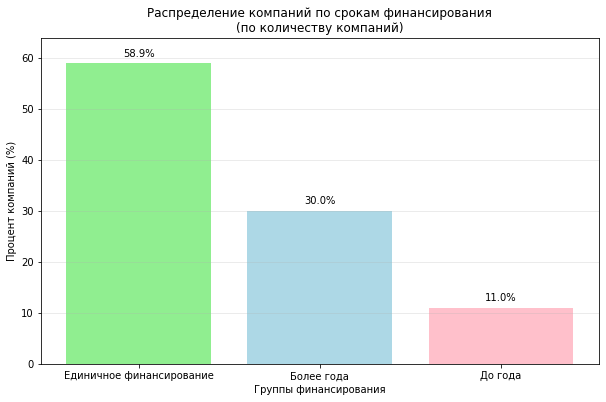

In [66]:
# По количеству компаний (в процентах)
group_counts = df_investments['funding_group'].value_counts()

# Задаем фиксированный порядок групп
group_counts = group_counts.reindex(groups_order)
total_companies = len(df_investments)
percents = (group_counts.values / total_companies) * 100

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
plt.bar(group_counts.index, 
        percents, 
        color=[color_mapping[group] for group in group_counts.index])
plt.title('Распределение компаний по срокам финансирования\n(по количеству компаний)')
plt.xlabel('Группы финансирования')
plt.ylabel('Процент компаний (%)')

# Добавляем подписи значений на столбцах
for i, value in enumerate(percents):
    plt.text(i, value + 1, f'{value:.1f}%', 
             ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(percents) + 5) 
plt.show()

Теперь посмотрим распределение компаний по срокам финансирования (по объему инвестиций, в долларах):

In [67]:
# Распределение компаний по объему инвестиций
group_investment = df_investments.groupby('funding_group')['funding_total_usd'].sum()
group_investment

funding_group
Более года                  402706207604
До года                      48885981057
Единичное финансирование    199303424483
Name: funding_total_usd, dtype: int64

Визуализируем соотношение групп по объему инвестиций, отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

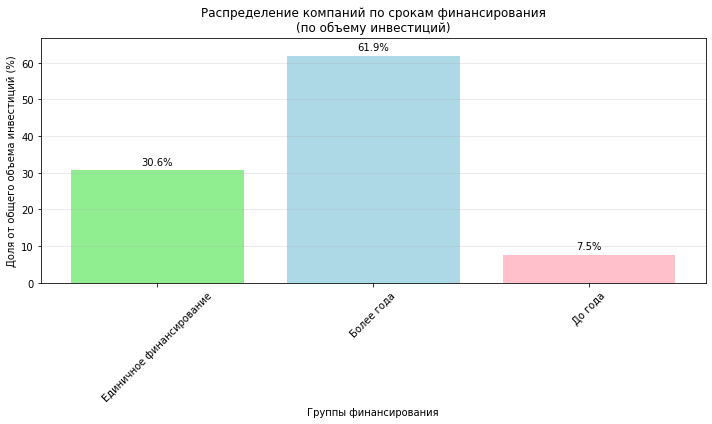

In [68]:
# По объему инвестиций (в процентах)
group_investment = df_investments.groupby('funding_group')['funding_total_usd'].sum()

# Задаем фиксированный порядок групп
group_investment = group_investment.reindex(groups_order)
total_investment = group_investment.sum()
percentages = (group_investment.values / total_investment) * 100

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
plt.bar(group_investment.index, 
        percentages, 
        color=[color_mapping[group] for group in group_investment.index])
plt.title('Распределение компаний по срокам финансирования\n(по объему инвестиций)')
plt.xlabel('Группы финансирования')
plt.ylabel('Доля от общего объема инвестиций (%)')

# Добавляем подписи значений на столбцах
for i, value in enumerate(percentages):
    plt.text(i, value + 1, f'{value:.1f}%', 
             ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.ylim(0, max(percentages) + 5)  
plt.tight_layout()
plt.show()

Больше половины стартапов (59%) получают деньги только один раз и дальше не развиваются с помощью инвесторов. 

При этом основные деньги (62%) получают компании, которые финансируются долго (больше года)

Получается, инвесторы предпочитают вкладывать крупные суммы в проекты с долгой историей, а не раздавать понемногу всем подряд. Компании с быстрым финансированием (до года) почти не получают серьезных денег - всего 7.5% от общего объема инвестиций.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Сначала проанализируем столбец market, чтобы определить распределение компаний по сегментам рынка. Мы рассчитаем частоту каждого сегмента и классифицируем их на три категории: массовые (более 120 компаний), средние (35-120 компаний) и нишевые (менее 35 компаний). Это поможет понять структуру рынка и выделить ключевые сегменты для дальнейшего анализа.

In [69]:
# Смотрим сегменты рынка
market_counts = df_investments['market'].value_counts()
market_counts

SOFTWARE                 4812
BIOTECHNOLOGY            3590
UNKNOWN MARKET           2503
MOBILE                   2343
E-COMMERCE               1866
                         ... 
DOMAINS                     1
HIGH TECH                   1
LOYALTY PROGRAMS            1
INCUBATORS                  1
DIGITAL ENTERTAINMENT       1
Name: market, Length: 395, dtype: int64

Теперь классифицируем сегменты на три категории по количеству компаний и посчитаем, сколько сегментов попадает в каждую категорию.

In [70]:
# Классификация сегментов
massive_segments = market_counts[market_counts > 120]
medium_segments = market_counts[(market_counts >= 35) & (market_counts <= 120)]
niche_segments = market_counts[market_counts < 35]

# Результаты классификации
print(f"Массовые сегменты (более 120 компаний): {len(massive_segments)}")
print(f"Средние сегменты (35-120 компаний): {len(medium_segments)}")
print(f"Нишевые сегменты (менее 35 компаний): {len(niche_segments)}")

# Статистика по количеству компаний
print(f"\nДополнительная статистика:")
print(f"Всего компаний в массовых сегментах: {massive_segments.sum()}")
print(f"Всего компаний в средних сегментах: {medium_segments.sum()}")
print(f"Всего компаний в нишевых сегментах: {niche_segments.sum()}")

Массовые сегменты (более 120 компаний): 49
Средние сегменты (35-120 компаний): 57
Нишевые сегменты (менее 35 компаний): 289

Дополнительная статистика:
Всего компаний в массовых сегментах: 36234
Всего компаний в средних сегментах: 3839
Всего компаний в нишевых сегментах: 830


Для визуализации распределения компаний по сегментам рынка построим столбчатую диаграмму с логарифмической шкалой, чтобы учесть длинные хвосты распределения. Используем цвета для выделения разных категорий сегментов.

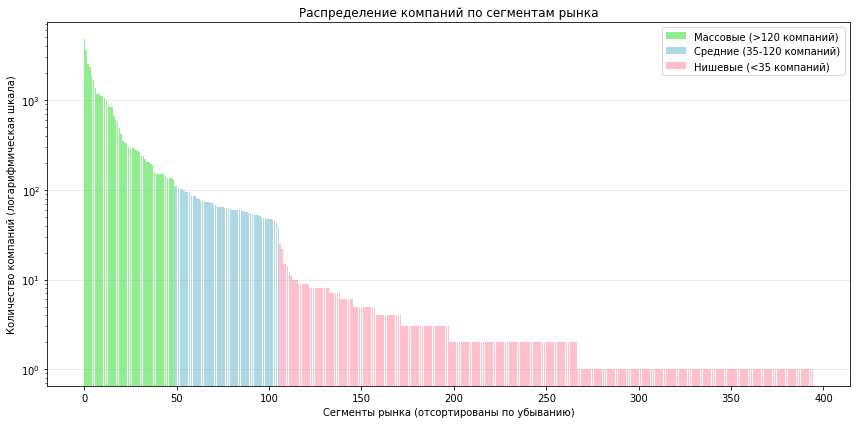

In [71]:
# Визуализация распределения сегментов
plt.figure(figsize=(12, 6))

# Создаем цветовую схему для разных категорий сегментов
colors = []
for count in market_counts.values:
    if count > 120:
        colors.append('lightgreen')  # Массовые сегменты
    elif count >= 35:
        colors.append('lightblue')   # Средние сегменты
    else:
        colors.append('pink')        # Нишевые сегменты

# Строим столбчатую диаграмму
plt.bar(range(len(market_counts)), 
        market_counts.values, 
        color=colors)

plt.yscale('log')  # Логарифмическая шкала для оси Y
plt.title('Распределение компаний по сегментам рынка')
plt.xlabel('Сегменты рынка (отсортированы по убыванию)')
plt.ylabel('Количество компаний (логарифмическая шкала)')


# Добавляем сетку для лучшей читаемости
plt.grid(axis='y', alpha=0.3)

# Создаем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', label='Массовые (>120 компаний)'),
    Patch(facecolor='lightblue', label='Средние (35-120 компаний)'),
    Patch(facecolor='pink', label='Нишевые (<35 компаний)')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

Мы хотим упростить анализ данных, оставив в столбце market только массовые сегменты (более 120 компаний), а все остальные сегменты заменим на общие категории. Для средних сегментов (35-120 компаний) будем использовать заглушку "MID", а для нишевых (менее 35 компаний) - "NICHE". 

In [72]:
# Создаем копию столбца market для работы
new_market = df_investments['market'].copy()

# Получаем список всех уникальных сегментов
all_segments = df_investments['market'].unique()

# Считаем количество компаний в каждом сегменте
segment_counts = df_investments['market'].value_counts()

# Проходим по всем сегментам и заменяем их на заглушки
for segment in all_segments:
    count = segment_counts[segment]
    if count > 120:
        # Оставляем массовые сегменты без изменений
        continue
    elif count >= 35:
        # Заменяем средние сегменты на MID
        new_market = new_market.replace(segment, 'MID')
    else:
        # Заменяем нишевые сегменты на NICHE
        new_market = new_market.replace(segment, 'NICHE')

# Заменяем исходный столбец на обработанный, тк все дальнейшие исследования нужно выполнять с учётом этой замены
df_investments['market'] = new_market

# Проверяем результат
df_investments['market'].value_counts()

SOFTWARE                4812
MID                     3839
BIOTECHNOLOGY           3590
UNKNOWN MARKET          2503
MOBILE                  2343
E-COMMERCE              1866
CURATED WEB             1693
ENTERPRISE SOFTWARE     1381
HEALTH CARE             1185
CLEAN TECHNOLOGY        1180
GAMES                   1117
ADVERTISING             1107
HARDWARE + SOFTWARE     1062
SOCIAL MEDIA            1003
HEALTH AND WELLNESS      872
EDUCATION                844
NICHE                    830
FINANCE                  828
ANALYTICS                667
MANUFACTURING            596
SECURITY                 567
SEMICONDUCTORS           484
WEB HOSTING              424
CONSULTING               349
HOSPITALITY              336
TRAVEL                   330
FASHION                  303
NEWS                     301
MESSAGING                295
SEARCH                   291
REAL ESTATE              279
SAAS                     272
MUSIC                    264
INTERNET                 241
TECHNOLOGY    

Анализ распределения компаний по сегментам рынка выявил четкую иерархическую структуру венчурного рынка. Всего мы насчитали 395 разных направлений, но большинство из них (289) - это нишевые сегменты с малым количеством компаний. Это говорит о том, что рынок стартапов очень разнообразный, но в основном состоит из мелких специализированных направлений.

Самыми популярными оказались массовые сегменты вроде Software (4812 компаний), Biotechnology (3590) и Mobile (2343). Хотя таких направлений всего 49, они собирают подавляющее большинство стартапов - 88% всех компаний. Это логично, ведь именно в этих областях проще масштабировать бизнес и привлекать крупные инвестиции.

Средние сегменты занимают промежуточное положение - их 57, и в них работает 3839 компаний. Общая картина показывает, что венчурный капитал концентрируется в проверенных и перспективных направлениях, где выше шансы на успех и возврат инвестиций.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

* Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

* По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

Чтобы визуально оценить распределение общего финансирования компаний, построим гистограмму и диаграмму размаха для столбца funding_total_usd. Это поможет определить типичный диапазон инвестиций и выявить выбросы. Гистограмма покажет форму распределения, а ящик с усами покажет медиану, квартили и аномальные значения.

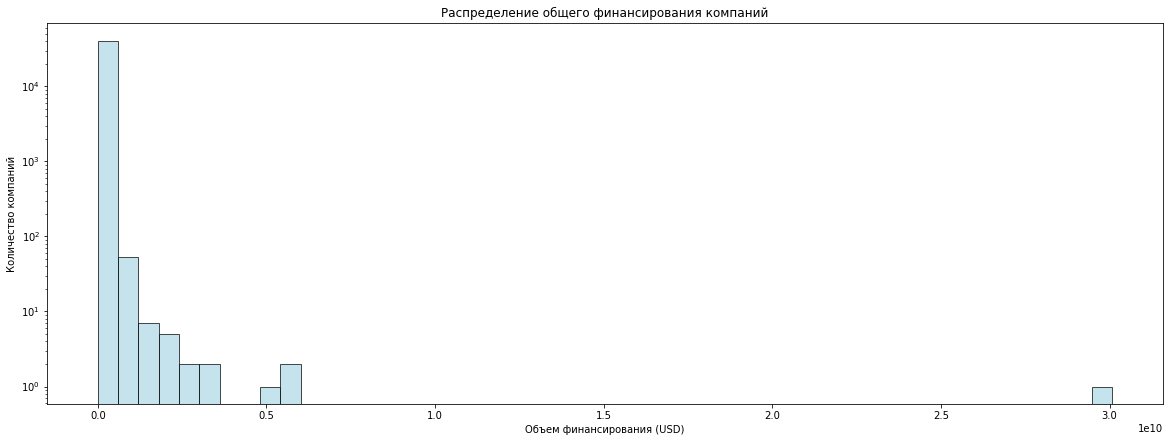

In [73]:
# Строим гистограмму для визуализации распределения
plt.figure(figsize=(20, 7))

# Гистограмма
plt.hist(df_investments['funding_total_usd'], 
         bins=50, 
         color='lightblue', 
         edgecolor='black', 
         alpha=0.7)

plt.title('Распределение общего финансирования компаний')
plt.xlabel('Объем финансирования (USD)')
plt.ylabel('Количество компаний')
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации

Большинство значений сосредоточено в левой части, а выбросы растягивают график.

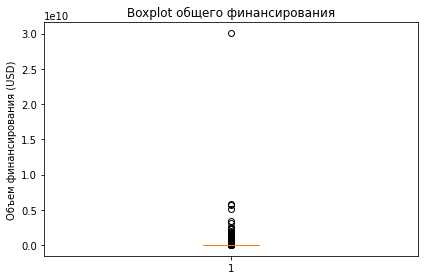

In [74]:
# Диаграмма размаха для выявления выбросов

plt.boxplot(df_investments['funding_total_usd'])
plt.title('Boxplot общего финансирования')
plt.ylabel('Объем финансирования (USD)')

plt.tight_layout()
plt.show()

Не очень-то информативно. Построим диаграмму размаха без крайних выбросов, ограничив диапазон значений. Это позволит лучше рассмотреть основную массу данных.

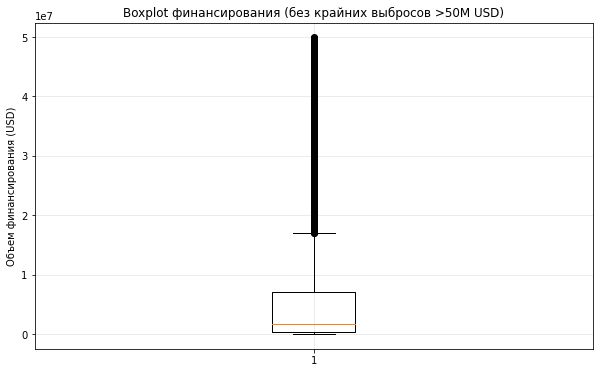

In [75]:
# Диаграмма размаха без крайних выбросов
plt.figure(figsize=(10, 6))

data_cropped = df_investments['funding_total_usd'][df_investments['funding_total_usd'] < 50000000]  # Ограничим 50 миллионов
plt.boxplot(data_cropped)

plt.title('Boxplot финансирования (без крайних выбросов >50M USD)')
plt.ylabel('Объем финансирования (USD)')

plt.grid(True, alpha=0.3)
plt.show()

In [77]:
# Рассчитаем основные статистики для определения типичного диапазона
stats = df_investments['funding_total_usd'].describe().round(0).astype(int)
stats

count          40903
mean        15913151
std        168687019
min                1
25%           350000
50%          2000000
75%         10000000
max      30079503000
Name: funding_total_usd, dtype: int64

In [79]:
# Определяем типичный размер финансирования как медиану
typical_funding = stats['50%']
print(f"Типичный размер финансирования: ${typical_funding:,} USD")

Типичный размер финансирования: $2,000,000 USD


Типичный размер финансирования это одно значение, а не диапазон. Медиана (2 миллиона долларов) лучше отражает типичный случай, чем среднее значение, так как она не искажается экстремальными выбросами. 50% всех компаний получили финансирование меньше или равное этой сумме, что делает её репрезентативной мерой типичного размера инвестиций.

Анализ распределения финансирования стартапов показывает ярко выраженную асимметрию - большинство компаний получают относительно небольшие инвестиции, в то время как небольшое количество проектов привлекает колоссальные суммы. Типичный диапазон финансирования составляет от 350 тысяч до 10 миллионов долларов, что охватывает 50% всех компаний в датасете. Медианное значение в 2 миллиона долларов лучше отражает типичную ситуацию, чем среднее значение в 16 миллионов, которое сильно завышено из-за экстремальных выбросов.

Особенно показательно, что 75% всех стартапов получают не более 10 миллионов долларов, что задает реалистичные ожидания для новых инвесторов. При этом наличие компаний с финансированием свыше 30 миллиардов долларов демонстрирует потенциал рынка для масштабирования, хотя такие случаи являются скорее исключением, чем правилом. Такое распределение характерно для венчурных инвестиций, где большинство проектов остаются в умеренном ценовом диапазоне, а рекордные суммы приходятся на единичные "выстрелившие" проекты.

* Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

* Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

Мы хотим найти компании, которые получили необычно много денег по сравнению с другими компаниям в своей категории. Будем считать выбросами те компании, у которых финансирование больше, чем у 75% компаний их сегмента плюс еще 1.5 разницы между 75% и 25%.

In [80]:
# Создаем столбец для отметки выбросов
df_investments['is_outlier'] = False

# Смотрим все уникальные сегменты рынка
all_markets = df_investments['market'].unique()

# Для каждого сегмента находим выбросы
for market in all_markets:
    # Берем только компании этого сегмента
    market_companies = df_investments[df_investments['market'] == market]
    
    # Считаем границы для нормальных значений
    Q1 = market_companies['funding_total_usd'].quantile(0.25)  # 25% компаний получают меньше этой суммы
    Q3 = market_companies['funding_total_usd'].quantile(0.75)  # 75% компаний получают меньше этой суммы
    IQR = Q3 - Q1  # разница между 75% и 25%
    upper_bound = Q3 + 1.5 * IQR  # верхняя граница нормальных значений
    
    # Отмечаем выбросы (те, у кого финансирование выше верхней границы)
    outliers = market_companies[market_companies['funding_total_usd'] > upper_bound]
    df_investments.loc[outliers.index, 'is_outlier'] = True

# Считаем сколько всего выбросов
outlier_count = df_investments['is_outlier'].sum()
total_companies = len(df_investments)
outlier_count

5244

Новый столбец is_outlier содержит булевы значения (True/False), где True означает, что компания является выбросом в своем рыночном сегменте по объему финансирования, а False - что компания находится в пределах нормального диапазона финансирования для своего рынка.

В процентах от общего количества

In [81]:
# Считаем процент выбросов
outlier_percents = round((outlier_count / total_companies) * 100, 2)
outlier_percents

12.82

Теперь посмотрим, в каких сегментах больше всего таких "особенных" компаний с огромным финансированием.

In [82]:
# Считаем для каждого сегмента
outliers_segments = []

for market in all_markets:
    market_companies = df_investments[df_investments['market'] == market]
    total = len(market_companies)
    outliers = market_companies['is_outlier'].sum()
    
    if total > 0:  # чтобы не делить на ноль
        percentage = outliers / total * 100
        outliers_segments.append([market, total, outliers, percentage])  # ИСПРАВЛЕНО

# Создаем таблицу с результатами
outliers_segments_df = pd.DataFrame(outliers_segments, columns=['market', 'total_companies', 'outliers', 'outlier_percentage'])  # ИСПРАВЛЕНО

# Сортируем по проценту выбросов (от большего к меньшему)
outliers_segments_df = outliers_segments_df.sort_values('outlier_percentage', ascending=False)

# Выводим топ-10 сегментов по проценту выбросов
for i in range(min(10, len(outliers_segments_df))):
    row = outliers_segments_df.iloc[i]
    print(f"{i+1}. {row['market']}: {row['outlier_percentage']:.1f}% ({row['outliers']} из {row['total_companies']})")

1. REAL ESTATE: 17.2% (48 из 279)
2. ENTERTAINMENT: 16.7% (25 из 150)
3. CONSULTING: 16.6% (58 из 349)
4. SEARCH: 16.5% (48 из 291)
5. CLOUD COMPUTING: 16.4% (25 из 152)
6. PHOTOGRAPHY: 16.2% (33 из 204)
7. SAAS: 16.2% (44 из 272)
8. TECHNOLOGY: 16.0% (38 из 238)
9. VIDEO: 16.0% (30 из 188)
10. NICHE: 15.9% (132 из 830)


Построим линейчатую диаграмму топ-10 сегментов по проценту выбросов

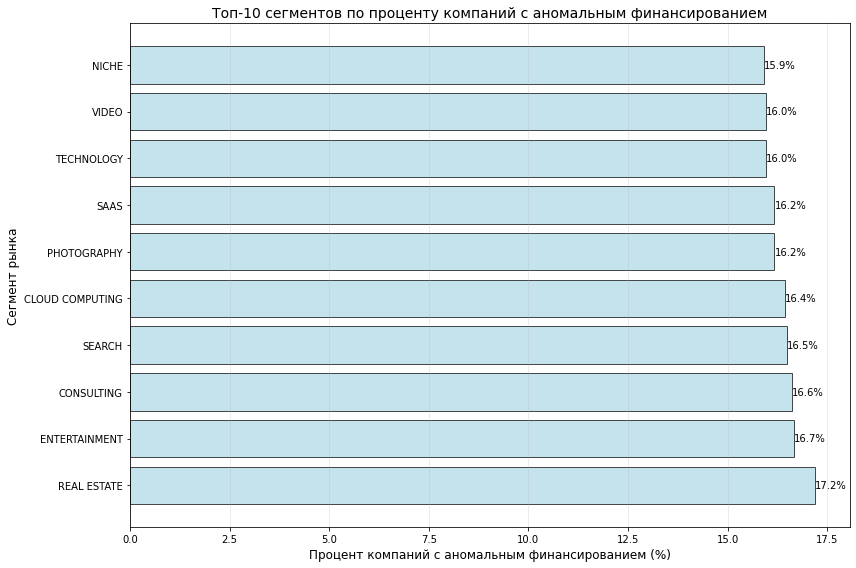

In [83]:
# Берем топ-10 сегментов по проценту выбросов
top_10_outliers = outliers_segments_df.head(10)

# Строим линейчатую диаграмму
plt.figure(figsize=(12, 8))
bars = plt.barh(top_10_outliers['market'], 
                top_10_outliers['outlier_percentage'], 
                color='lightblue',
                edgecolor='black',
                alpha=0.7)

plt.title('Топ-10 сегментов по проценту компаний с аномальным финансированием', fontsize=14)
plt.xlabel('Процент компаний с аномальным финансированием (%)', fontsize=12)
plt.ylabel('Сегмент рынка', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Добавляем подписи значений на каждый столбец
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Анализ показал, что в среднем 13% компаний в каждом сегменте получают аномально высокое финансирование - значительно больше, чем остальные. Самые неравномерные рынки - недвижимость и развлечения, где больше 16% компаний становятся "звездами" с огромными инвестициями.

Интересно, что даже в нишевых направлениях есть свои лидеры, которые привлекают непропорционально большие деньги. 

Это подтверждает правило венчурных инвестиций: успех концентрируется вокруг немногих перспективных проектов, в то время как большинство компаний довольствуются скромным финансированием. В каждом сегменте есть свои фавориты, которые получают основную часть денег.

Создадим классификацию сегментов для дальнейшего использования:

In [84]:
# Создаем классификацию на основе обработанного столбца market
def classify_segment_corrected(market):
    if market == 'MID':
        return 'medium'
    elif market == 'NICHE':
        return 'niche'
    else:
        return 'massive'  # все остальные - массовые сегменты

# Применяем классификацию
df_investments['segment_category'] = df_investments['market'].apply(classify_segment_corrected)

# Проверяем результат
print("Распределение компаний по категориям сегментов:")
print(df_investments['segment_category'].value_counts())

Распределение компаний по категориям сегментов:
massive    36234
medium      3839
niche        830
Name: segment_category, dtype: int64


Посчитаем процент выбросов для каждой категории:

In [85]:
# Считаем количество выбросов в каждой категории сегментов
outliers_by_category = df_investments.groupby('segment_category')['is_outlier'].agg(['sum', 'count'])

# Переименовываем столбцы для понятности
outliers_by_category = outliers_by_category.rename(columns={'sum': 'outliers_count', 'count': 'total_companies'})

# Рассчитываем процент выбросов в каждой категории
outliers_by_category['outlier_percentage'] = (outliers_by_category['outliers_count'] / outliers_by_category['total_companies'] * 100).round(2)

print("Доля компаний с аномальным финансированием по категориям сегментов:")
outliers_by_category

Доля компаний с аномальным финансированием по категориям сегментов:


,outliers_count,total_companies,outlier_percentage
segment_category,,,
massive,4556,36234,12.57
medium,556,3839,14.48
niche,132,830,15.90


Построим столбчатую диаграмму

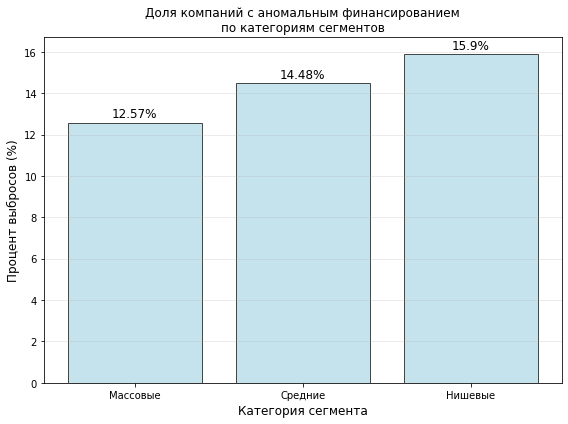

In [86]:
# Строим столбчатую диаграмму доли выбросов по категориям сегментов
categories = ['Массовые', 'Средние', 'Нишевые']
outlier_percentages = [outliers_by_category.loc['massive', 'outlier_percentage'],
                      outliers_by_category.loc['medium', 'outlier_percentage'], 
                      outliers_by_category.loc['niche', 'outlier_percentage']]

plt.figure(figsize=(8, 6))

bars = plt.bar(categories, 
               outlier_percentages,
               color='lightblue',
               edgecolor='black',
               alpha=0.7)

plt.title('Доля компаний с аномальным финансированием\nпо категориям сегментов', fontsize=12)
plt.ylabel('Процент выбросов (%)', fontsize=12)
plt.xlabel('Категория сегмента', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений на столбцах
for bar, percentage in zip(bars, outlier_percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{percentage}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

Анализ показывает четкую закономерность: чем более нишевым является сегмент рынка, тем выше в нем доля компаний с аномальным финансированием. В нишевых сегментах почти 16% компаний получают экстремально высокие инвестиции, тогда как в массовых сегментах таких компаний всего 12.6%.

Это говорит о том, что инвесторы делают более крупные, но менее частые ставки на перспективные нишевые направления, в то время как в массовых сегментах инвестиции распределяются более равномерно. 

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

* Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

* Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

Сначала нам нужно соединить датасеты инвестиций и возвратов. Поскольку у нас есть временной ряд возвратов по годам, а в инвестициях есть даты финансирования, мы будем использовать левое соединение (left join) по году финансирования. Это позволит добавить информацию о возвратах к каждой компании на основе года её финансирования.

In [87]:
# Добавляем год финансирования к основному датасету
df_investments['funding_year'] = df_investments['mid_funding_at'].dt.year

# Выполняем левое соединение с df_returns
df = df_investments.merge(
    df_returns, 
    left_on='funding_year', 
    right_index=True, 
    how='left'
)

Смотрим, что получилось

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40903 entries, 0 to 49437
Data columns (total 58 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   name                         40903 non-null  object        
 1   homepage_url                 40903 non-null  object        
 2   category_list                40903 non-null  object        
 3   market                       40903 non-null  object        
 4   funding_total_usd            40903 non-null  int64         
 5   status                       40903 non-null  object        
 6   country_code                 40903 non-null  object        
 7   state_code                   40903 non-null  object        
 8   region                       40903 non-null  object        
 9   city                         40903 non-null  object        
 10  funding_rounds               40903 non-null  int64         
 11  participants                 27328 non-nu

In [89]:
df.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,undisclosed_return,convertible_note_return,debt_financing_return,angel_return,grant_return,private_equity_return,post_ipo_equity_return,post_ipo_debt_return,secondary_market_return,product_crowdfunding_return
0,HARVARD UNIVERSITY,HTTP://HARVARD.EDU,EDUCATION,EDUCATION,90000000,OPERATING,USA,MA,BOSTON,CAMBRIDGE,...,105720000.0,7870000.0,1.017750e+09,293980000.0,0.0,384010000.0,262700000.0,37200000.0,1030000.0,720000.0
1,UNIVERSITY OF NEW BRUNSWICK,HTTP://WWW.UNB.CA,UNKNOWN CATEGORY,UNKNOWN MARKET,2000000,OPERATING,UNKNOWN COUNTRY,UNKNOWN STATE,UNKNOWN REGION,UNKNOWN CITY,...,105720000.0,7870000.0,1.017750e+09,293980000.0,0.0,384010000.0,262700000.0,37200000.0,1030000.0,720000.0
2,DUPONT,HTTP://WWW.DUPONT.COM,BUSINESS SERVICES|AGRICULTURE|AUTOMOTIVE|INVES...,MID,9000000,OPERATING,USA,DE,"WILMINGTON, DELAWARE",WILMINGTON,...,37500000.0,2250000.0,3.941000e+08,97210000.0,0.0,203700000.0,76760000.0,0.0,120000.0,20000.0
3,UNIVERSITY OF MICHIGAN,HTTP://WWW.UMICH.EDU/,EDUCATION,EDUCATION,7700000,OPERATING,USA,MI,DETROIT,ANN ARBOR,...,84400000.0,6000000.0,8.486500e+08,225870000.0,0.0,988530000.0,219930000.0,30450000.0,810000.0,340000.0
4,CASE WESTERN RESERVE UNIVERSITY,HTTP://WWW.CASE.EDU,EDUCATION,EDUCATION,540000,OPERATING,USA,OH,CLEVELAND,CLEVELAND,...,105720000.0,7870000.0,1.017750e+09,293980000.0,0.0,384010000.0,262700000.0,37200000.0,1030000.0,720000.0
5,XAVIER UNIVERSITY,HTTP://WWW.XAVIER.EDU/,UNKNOWN CATEGORY,UNKNOWN MARKET,19000000,OPERATING,USA,OH,CINCINNATI,CINCINNATI,...,105720000.0,7870000.0,1.017750e+09,293980000.0,0.0,384010000.0,262700000.0,37200000.0,1030000.0,720000.0
6,TULANE UNIVERSITY,HTTP://TULANE.EDU/,EDUCATION,EDUCATION,12000000,OPERATING,USA,LA,NEW ORLEANS,NEW ORLEANS,...,84400000.0,6000000.0,8.486500e+08,225870000.0,0.0,988530000.0,219930000.0,30450000.0,810000.0,340000.0
7,DUKE UNIVERSITY,HTTP://WWW.DUKE.EDU,EDUCATION,EDUCATION,8700000,OPERATING,USA,NC,RALEIGH,DURHAM,...,105720000.0,7870000.0,1.017750e+09,293980000.0,0.0,384010000.0,262700000.0,37200000.0,1030000.0,720000.0
8,"VIRGINIA COMMONWEALTH UNIVERSITY, RICHMOND",HTTP://WWW.VCU.EDU/,UNKNOWN CATEGORY,UNKNOWN MARKET,6000000,OPERATING,USA,VA,RICHMOND,RICHMOND,...,105720000.0,7870000.0,1.017750e+09,293980000.0,0.0,384010000.0,262700000.0,37200000.0,1030000.0,720000.0
9,WEGAME,HTTP://WWW.WEGAME.COM,SOCIAL MEDIA,SOCIAL MEDIA,3500000,ACQUIRED,USA,CA,SF BAY AREA,SAN FRANCISCO,...,55370000.0,3220000.0,1.256800e+08,164510000.0,0.0,88810000.0,24360000.0,0.0,570000.0,0.0


Выглядит нормально. 

Теперь проверим полноту данных за 2014 год. Посмотрим, есть ли компании с финансированием в 2014 году и насколько эти данные полные.

In [90]:
# Проверяем данные за 2014 год
companies_2014 = df[df['funding_year'] == 2014]

# Сколько компаний с финансированием в 2014
len(companies_2014)

6619

In [91]:
# Минимальная дата финансирования в 2014
companies_2014['mid_funding_at'].min()

Timestamp('2014-01-01 00:00:00')

In [92]:
# Максимальная дата финансирования в 2014
companies_2014['mid_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

In [93]:
# Проверяем распределение по месяцам 2014 года
if len(companies_2014) > 0:
    monthly_counts = companies_2014['mid_funding_at'].dt.month.value_counts().sort_index()

monthly_counts

1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64

Данные за 2014 год выглядят противоречиво. Несмотря на то, что даты финансирования охватывают весь год, видно резкое падение количества раундов финансирования в ноябре и особенно в декабре (всего 23 раунда). Это нетипично для равномерного распределения в течение года. Вероятно, данные включают не все сделки, особенно за последние месяцы, либо по каким-то причинам произошло снижение инвестиционной активности.

Исключаем компании с аномальным финансированием, которые мы пометили ранее.

In [94]:
# Исключаем компании с аномальным финансированием
before_filter = len(df)
df_filtered = df[~df['is_outlier']]
after_filter = len(df_filtered)

# Смотрим, сколько компаний осталось
after_filter

35659

In [95]:
# Сколько компаний с аномальным финансированием исключено
before_filter - after_filter

5244

In [96]:
# Процент исключенных: 
filter_percent = round((before_filter - after_filter) / before_filter * 100, 2)
filter_percent

12.82

Теперь определим годы, когда было 50 или более раундов финансирования, и оставим только компании, которые получали финансирование в эти годы.

In [97]:
# Считаем количество раундов финансирования по годам
funding_rounds_by_year = df_filtered.groupby('funding_year')['funding_rounds'].sum()
funding_rounds_by_year.sort_values(ascending=False)

funding_year
2013    12880
2012     9705
2011     7576
2014     7122
2010     6135
2009     4617
2008     3663
2007     2842
2006     1849
2005      948
2004      181
2003      125
2000      113
2002       98
2001       66
1999       43
1998       15
1995        9
1996        8
1997        5
1992        5
1994        4
1985        3
1982        3
1960        2
1987        2
1984        2
1993        1
1990        1
1989        1
1983        1
1979        1
1921        1
Name: funding_rounds, dtype: int64

In [98]:
# Находим годы с 50 или более раундами финансирования
active_years = funding_rounds_by_year[funding_rounds_by_year >= 50].index
sorted(active_years)

[2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014]

In [99]:
# Оставляем только компании, которые финансировались в активные годы
df_final = df_filtered[df_filtered['funding_year'].isin(active_years)]

# Смотрим количество таких корманий
len(df_final)

35585

После фильтрации данных исключено 12.8% компаний с аномальным финансированием, что составляет 5244 компании из исходного набора.

Основная активность финансирования сосредоточена в период с 2000 по 2014 год, причем пик пришелся на 2013 год с 12880 раундами. 

После применения всех фильтров в анализе остается 35585 компаний, что составляет репрезентативную выборку для дальнейшего исследования.

### 3.3. Анализ типов финансирования по объёму и популярности

* Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

* Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

* Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

Сначала нужно понять, какие типы финансирования привлекли больше всего денег в сумме. Просуммируем значения по всем столбцам с типами финансирования и отсортируем в порядке убывания:

In [100]:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# Суммируем и сортируем объемы финансирования
total_funding_sorted = df_final[funding_types].sum().sort_values(ascending=False)

for fund_type, amount in total_funding_sorted.items():
    print(f"{fund_type: <25} ${amount:>12,.0f}")

venture                   $129,089,068,088
seed                      $9,430,681,895
debt_financing            $8,178,152,734
private_equity            $4,825,108,504
angel                     $2,481,263,836
undisclosed               $2,100,352,252
grant                     $1,978,848,688
post_ipo_equity           $1,946,452,068
convertible_note          $ 566,039,436
post_ipo_debt             $ 286,718,349
equity_crowdfunding       $ 237,960,645
product_crowdfunding      $ 186,093,920
secondary_market          $  45,285,796


Построим столбчатую диаграмму для визуализации общего объема финансирования по типам. Используем логарифмическую шкалу из-за большого разброса значений. Это покажет, какие типы финансирования привлекли наибольшие суммы денег.

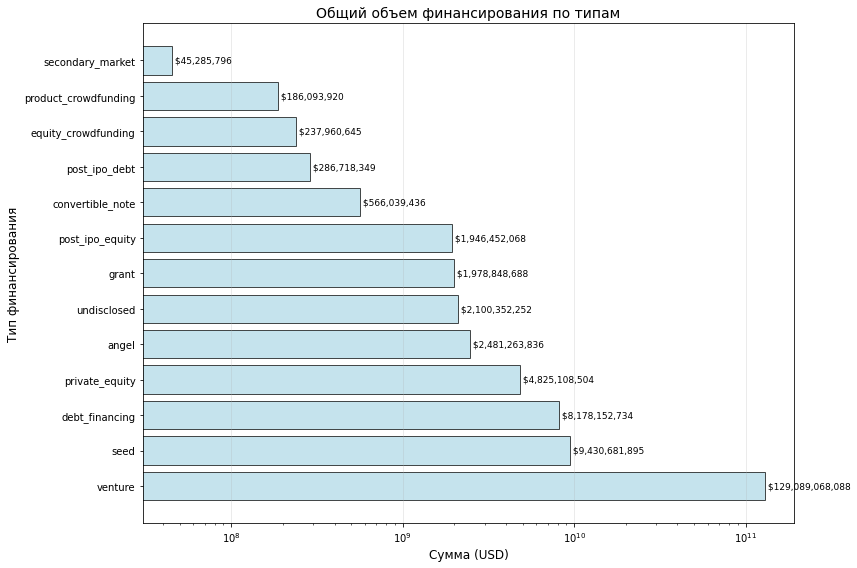

In [101]:
# Строим линейчатую диаграмму
plt.figure(figsize=(12, 8))
barh = plt.barh(total_funding_sorted.index, 
                total_funding_sorted.values, 
                color='lightblue',
                edgecolor='black',
                alpha=0.7)

plt.title('Общий объем финансирования по типам', fontsize=14)
plt.xlabel('Сумма (USD)', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.xscale('log')
plt.grid(axis='x', alpha=0.3)

# Добавляем подписи сумм на каждый столбец
for bar in barh:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' ${width:,.0f}',
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Венчурное финансирование является абсолютным лидером (привлекает 129 млрд долларов),более чем в 10 раз больше, чем следующий по объему тип (посевное финансирование - 9.4 млрд). Наибольшая концентрация капитала наблюдается в первых трех типах: венчурное, посевное и долговое финансирование, которые вместе составляют подавляющее большинство всех инвестиций. При этом вторичный рынок (secondary_market) показывает наименьший объем финансирования - всего 45 миллионов долларов, что почти в 3000 раз меньше лидирующего венчурного типа.

Проанализируем популярность разных типов финансирования. Для этого посчитаем, в скольких компаниях каждый тип финансирования встречается (не нулевые значения). Это покажет, какие формы инвестиций наиболее распространены среди стартапов. 

In [102]:
# Считаем популярность типов финансирования и сортируем
funding_popularity = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

# Выводим результаты
for fund_type, count in funding_popularity.items():
    percentage = (count / len(df_final)) * 100
    print(f"{fund_type: <20} {count:>5}")

venture              18818
seed                 13374
debt_financing        3265
angel                 2937
grant                 1003
undisclosed            813
private_equity         633
convertible_note       521
equity_crowdfunding    515
product_crowdfunding   204
post_ipo_equity        164
post_ipo_debt           27
secondary_market         7


Для визуализации популярности типов финансирования построим линейчатую диаграмму. Используем логарифмическую шкалу из-за большого разброса значений.

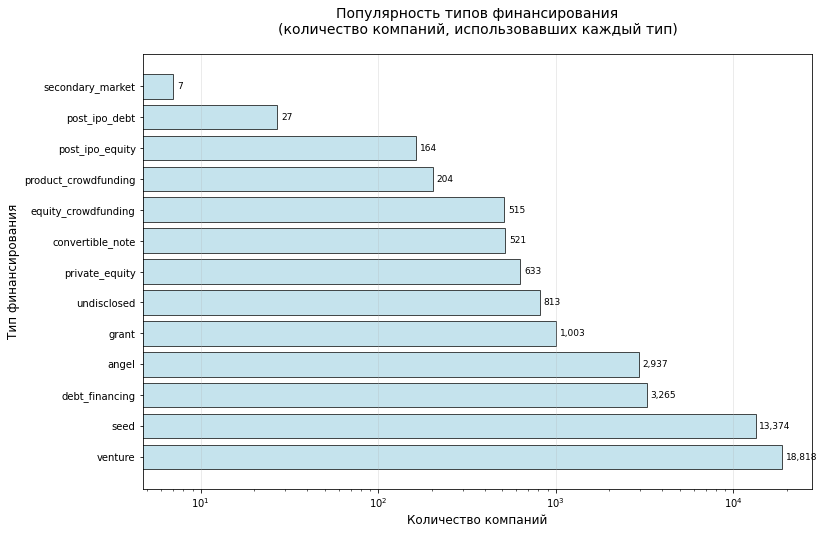

In [103]:
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
barh = plt.barh(funding_popularity.index,
                funding_popularity.values,
                color='lightblue',
                edgecolor='black',
                alpha=0.7)

plt.xlabel('Количество компаний', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.title('Популярность типов финансирования\n(количество компаний, использовавших каждый тип)', 
          fontsize=14, pad=20)

# Добавляем логарифмическую шкалу по оси X
plt.xscale('log')

# Добавляем сетку для удобства чтения
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на столбцы
for bar in barh:
    width = bar.get_width()
    plt.text(width * 1.05, bar.get_y() + bar.get_height()/2, 
             f'{width:,}', va='center', ha='left', fontsize=9)

plt.show()

Больше всего компаний используют венчурное и посевное финансирование - это самые популярные способы привлечения денег. Другие виды финансирования встречаются значительно реже. Некоторые типы финансирования почти не используются,например, вторичный рынок выбрали всего 7 компаний.

Анализ показывает четкое разделение типов финансирования. 

Венчурные инвестиции - самые популярные и самые крупные: их используют почти 19 тысяч компаний, и они привлекли 129 миллиардов долларов.

Есть виды финансирования, которые используют часто, но денег дают немного: это гранты и ангельские инвестиции. Их берут тысячи компаний, но суммы получаются сравнительно небольшие.

Есть редкие, но очень крупные виды финансирования: частные инвестиции и финансирование после IPO. Их выбирают немногие компании (сотни), но каждая получает огромные деньги, миллиарды долларов.

Конвертируемый заем используют достаточно часто, но суммы всегда небольшие, что говорит о его роли для мелких сделок.

* Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

* Проанализируем суммарные объемы возвратов от разных типов финансирования за весь период (2000-2014 годы) на основе датасета df_returns. Это покажет, какие типы инвестиций приносят наибольший доход инвесторам.

In [104]:
# Считаем сумму возвратов для каждого типа
return_totals = df_returns.sum()

# Сортируем от большего к меньшему
return_totals = return_totals.sort_values(ascending=True)  # ascending=True для горизонтального графика

return_totals

grant_return                             0
product_crowdfunding_return        1860000
equity_crowdfunding_return         3830000
secondary_market_return            5200000
convertible_note_return           34790000
post_ipo_debt_return              91030000
undisclosed_return               730879999
post_ipo_equity_return          1104959999
angel_return                    1509230000
seed_return                     2382239999
private_equity_return           3587330000
debt_financing_return           4734850000
venture_return                 40578620000
dtype: int64

Теперь построим линейчатую диаграмму, которая покажет, какие типы финансирования принесли больше всего суммарных возвратов.

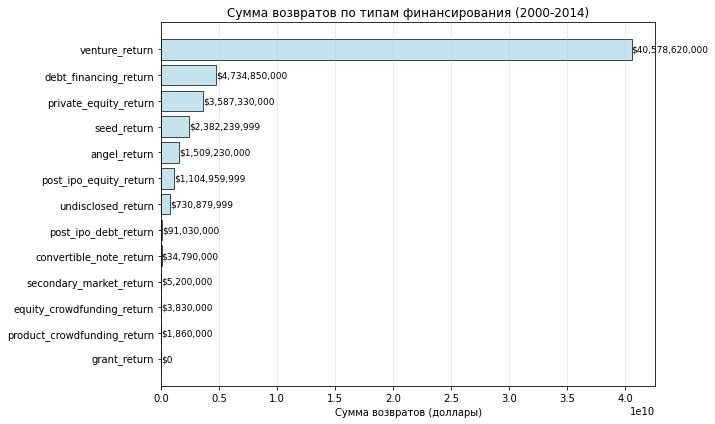

In [105]:
# Строим простой горизонтальный график
plt.figure(figsize=(10, 6))
bars = plt.barh(return_totals.index, 
                return_totals.values, 
                color='lightblue',
                edgecolor='black',
                alpha=0.7)

plt.title('Сумма возвратов по типам финансирования (2000-2014)')
plt.xlabel('Сумма возвратов (доллары)')
plt.grid(axis='x', alpha=0.3)

# Добавляем подписи с суммами
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(width, y, f'${width:,.0f}', va='center', ha='left', fontsize=9)
    
plt.tight_layout()
plt.show()

Почему-то не получается сюда сделать логарифмическую шкалу для наглядности ( при добавлении plt.xscale('log') код выдает ошибку, думаю, ошибка возникает из-за слишком больших числовых значений на логарифмической шкале)

Венчурное финансирование демонстрирует абсолютное лидерство по объему возвратов - 40.6 млрд долларов, что более чем в 8 раз превышает следующий результат (долговое финансирование - 4.7 млрд). При этом гранты показывают нулевую доходность, что логично, поскольку они не предполагают возврата средств. Наибольшую эффективность демонстрируют классические типы инвестиций: венчурное, долговое и частное акционерное финансирование.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

* Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).


* Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

Рассчитаем для каждой компании средний объем одного раунда финансирования, разделив общий объем финансирования на количество раундов. Это покажет, сколько в среднем денег компания получала за один раунд.

In [106]:
# Создаем копию датафрейма
df_final_copy = df_final.copy()

# Рассчитываем средний объем одного раунда финансирования для каждой компании
df_final_copy['avg_round_amount'] = df_final_copy['funding_total_usd'] / df_final_copy['funding_rounds']

Построим график динамики типичного размера раунда финансирования по годам. Будем использовать медиану, так как она менее чувствительна к выбросам, чем среднее значение.

In [107]:
# Рассчитываем медианный размер раунда по годам
median_round_by_year = df_final_copy.groupby('funding_year')['avg_round_amount'].median()
median_round_by_year

funding_year
2000    2.250000e+06
2001    1.570886e+06
2002    3.225000e+06
2003    1.500000e+06
2004    3.000000e+06
2005    4.500000e+06
2006    3.900000e+06
2007    2.879167e+06
2008    2.170744e+06
2009    1.498475e+06
2010    1.250000e+06
2011    8.676411e+05
2012    6.860000e+05
2013    5.590000e+05
2014    5.606250e+05
Name: avg_round_amount, dtype: float64

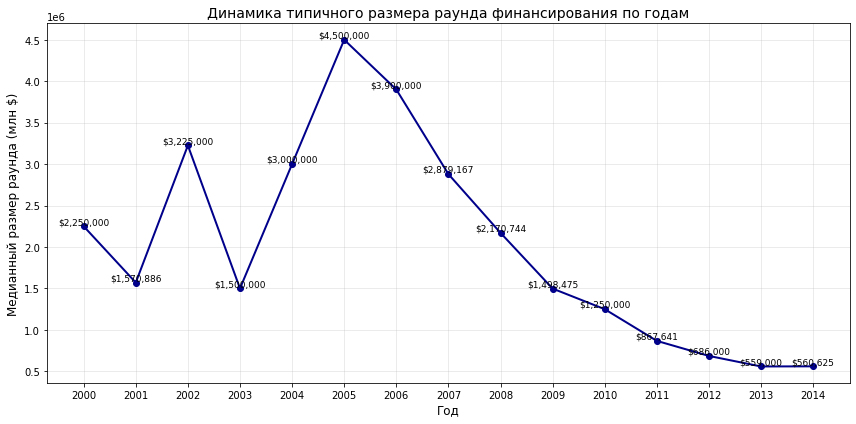

In [108]:
# Строим график динамики
plt.figure(figsize=(12, 6))
plt.plot(median_round_by_year.index, 
         median_round_by_year.values, 
         marker='o',
         linewidth=2,
         markersize=6,
         color='darkblue')

plt.title('Динамика типичного размера раунда финансирования по годам', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Медианный размер раунда (млн $)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(median_round_by_year.index)

# Добавляем подписи значений
for year, value in median_round_by_year.items():
    plt.text(year, value, f'${value:,.0f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Теперь построим график динамики общего количества раундов финансирования по годам. Это покажет активность инвестиционного рынка.

In [109]:
# Считаем общее количество раундов по годам
total_rounds_by_year = df_final_copy.groupby('funding_year')['funding_rounds'].sum()
total_rounds_by_year

funding_year
2000      113
2001       66
2002       98
2003      125
2004      181
2005      948
2006     1849
2007     2842
2008     3663
2009     4617
2010     6135
2011     7576
2012     9705
2013    12880
2014     7122
Name: funding_rounds, dtype: int64

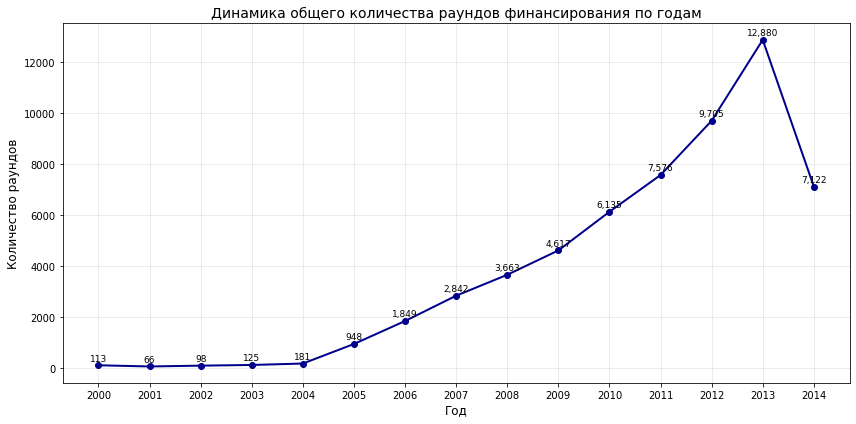

In [110]:
# Строим линейный график динамики
plt.figure(figsize=(12, 6))
plt.plot(total_rounds_by_year.index, 
         total_rounds_by_year.values, 
         marker='o',
        markersize=6,
         linewidth=2, 
         color='darkblue'
        )

plt.title('Динамика общего количества раундов финансирования по годам', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество раундов', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(total_rounds_by_year.index)

# Добавляем подписи значений
for year, value in total_rounds_by_year.items():
    plt.text(year, value + 100, f'{value:,}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Максимальный типичный размер средств в рамках одного раунда финансирования наблюдался в 2005 году и составлял 4.5 миллиона долларов. После этого пика произошло постепенное снижение размера раундов, что свидетельствует об изменении стратегий инвестирования.

В 2014 году проявилась противоречивая тенденция: с одной стороны, количество раундов финансирования значительно сократилось (7122 раунда против 12880 в 2013 году), что указывает на снижение инвестиционной активности. С другой стороны, средний размер раунда стабилизировался на уровне 560 тысяч долларов, что говорит о сохранении интереса к качественным проектам, несмотря на общее сокращение числа сделок. Это может свидетельствовать о более избирательном подходе инвесторов, которые предпочитают концентрировать ресурсы на перспективных стартапах, а не распылять их по множеству проектов. Либо, возможно, данные за 2014 год не полные. В реальном проекте мы бы это уточнили у заказчика.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

* Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

* На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

* На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

Создадим сводную таблицу с суммарным финансированием по годам и сегментам рынка:

In [111]:
# Создаем сводную таблицу с суммарным финансированием по годам и сегментам
pivot_table = pd.pivot_table(df_final_copy,
                            values='funding_total_usd',
                            index='market',
                            columns='funding_year',
                            aggfunc='sum',
                            fill_value=0)

pivot_table

funding_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
ADVERTISING,14470000,8778321,24500000,10500000,6000000,127196022,299299458,556704331,622673464,563446005,631617869,410730737,521137032,524915135,207792333
ANALYTICS,14822803,0,7500000,3840000,3000000,79014044,139701311,98829000,208077840,140949327,253739903,443333373,539214309,622821367,151461613
APPS,0,0,0,0,0,0,1310600,0,4300000,7219000,6123779,18374071,32601125,28868621,66237730
AUTOMOTIVE,0,0,0,4530000,0,22500000,12660000,37712601,59478635,20800311,17696916,76452163,35557677,117572526,69034162
BIG DATA,0,0,0,0,0,0,0,7780000,2452515,597375,39233297,60369158,86413341,78698922,79232600
BIOTECHNOLOGY,0,0,0,85531178,97184859,480063583,903500543,1704078338,1716033000,3915900521,4894500078,4967551850,4931138800,5694269809,2509638562
CLEAN TECHNOLOGY,0,0,34390435,50352939,50427954,19420000,131473889,749711239,3165808492,1963502838,1604429454,1545603337,958011189,1203060535,688686785
CLOUD COMPUTING,11500000,0,0,0,0,0,9951809,20354343,44375000,52223719,8525538,73151398,74421582,84846778,73440856
CONSULTING,4500000,0,0,0,0,44862000,23965548,70346345,19061080,62715165,81264877,43413397,65922756,93321324,54298022


Теперь отфильтруем сегменты, которые показали рост финансирования в 2014 году по сравнению с 2013.

In [112]:
# Отбираем сегменты с ростом финансирования в 2014 vs 2013
growth_segments = pivot_table[(pivot_table[2014] > pivot_table[2013]) & 
                             (pivot_table[2013] > 0)]  # Исключаем сегменты без данных за 2013

for segment in growth_segments.index:
    funding_2013 = growth_segments.loc[segment, 2013]
    funding_2014 = growth_segments.loc[segment, 2014]
    growth = ((funding_2014 - funding_2013) / funding_2013) * 100
    print(f"{segment:<25} ${funding_2013:<12} ${funding_2014:<12} {growth:>10.1f}%")

APPS                      $28868621     $66237730          129.4%
BIG DATA                  $78698922     $79232600            0.7%
DESIGN                    $60958835     $68988516           13.2%
INTERNET                  $69732096     $117830756          69.0%
MANUFACTURING             $393936634    $416332314           5.7%
MEDICAL                   $64469424     $175236064         171.8%
MID                       $1686905096   $1868755421         10.8%
NICHE                     $269904287    $738172920         173.5%
REAL ESTATE               $92207655     $115567364          25.3%
SAAS                      $79576613     $92807752           16.6%
STARTUPS                  $18080552     $41501837          129.5%
TECHNOLOGY                $120873887    $202018937          67.1%
UNKNOWN MARKET            $259004551    $609069074         135.2%


In [113]:
# Всего сегментов с ростом
len(growth_segments)

13

Сначала отфильтруем только массовые сегменты (исключим 'MID' и 'NICHE') и UNKNOWN MARKET (условие достаточности данных)

In [114]:
# Исключаем средние и нишевые сегменты (MID и NICHE), исключаем UNKNOWN MARKET
# Оставляем только массовые сегменты
massive_segments_growth = growth_segments[~growth_segments.index.isin(['MID', 'NICHE', 'UNKNOWN MARKET'])]

for segment in massive_segments_growth.index:
    funding_2013 = massive_segments_growth.loc[segment, 2013]
    funding_2014 = massive_segments_growth.loc[segment, 2014]
    growth = ((funding_2014 - funding_2013) / funding_2013) * 100
    print(f"{segment:<25} ${funding_2013/1e6:<10.1f}M ${funding_2014/1e6:<10.1f}M {growth:>10.1f}%")

APPS                      $28.9      M $66.2      M      129.4%
BIG DATA                  $78.7      M $79.2      M        0.7%
DESIGN                    $61.0      M $69.0      M       13.2%
INTERNET                  $69.7      M $117.8     M       69.0%
MANUFACTURING             $393.9     M $416.3     M        5.7%
MEDICAL                   $64.5      M $175.2     M      171.8%
REAL ESTATE               $92.2      M $115.6     M       25.3%
SAAS                      $79.6      M $92.8      M       16.6%
STARTUPS                  $18.1      M $41.5      M      129.5%
TECHNOLOGY                $120.9     M $202.0     M       67.1%


In [115]:
# Всего массовых сегментов с ростом
len(massive_segments_growth)

10

Построим график динамики суммарного финансирования для массовых сегментов с ростом за все доступные годы. Для большей наглядности используем логарифмическую шкалу

In [116]:
# Создаем сводную таблицу для массовых сегментов с ростом
massive_segments_growth = growth_segments[~growth_segments.index.isin(['MID', 'NICHE', 'UNKNOWN MARKET'])]
massive_pivot = pd.pivot_table(df_final_copy[df_final_copy['market'].isin(massive_segments_growth.index)],
                              values='funding_total_usd',
                              index='market',
                              columns='funding_year',
                              aggfunc='sum',
                              fill_value=0)

massive_segments_growth.index.tolist()

['APPS',
 'BIG DATA',
 'DESIGN',
 'INTERNET',
 'MANUFACTURING',
 'MEDICAL',
 'REAL ESTATE',
 'SAAS',
 'STARTUPS',
 'TECHNOLOGY']

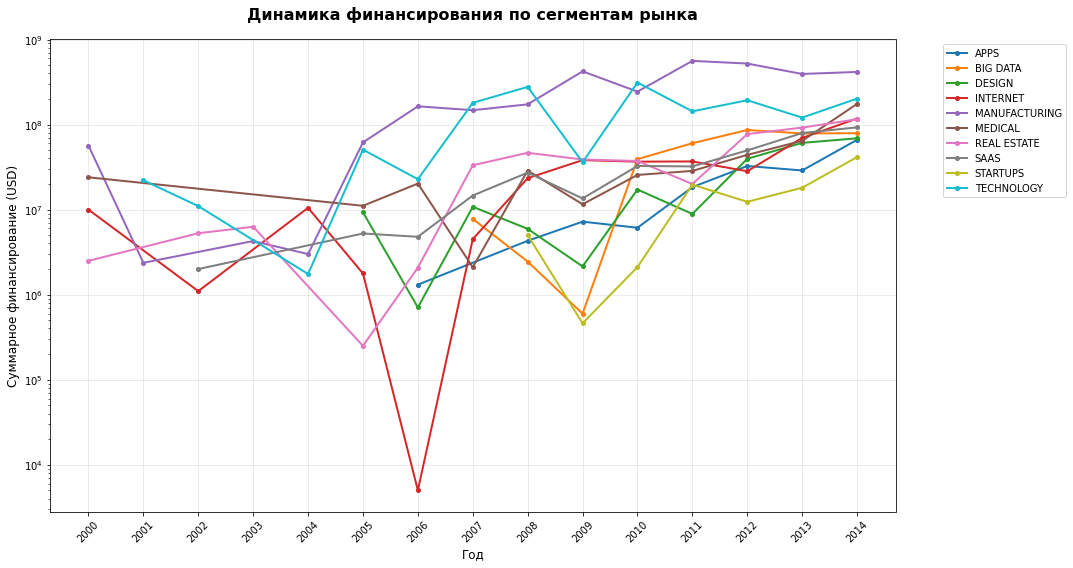

In [117]:
# Строим график с правильным отображением начала данных для каждого сегмента
plt.figure(figsize=(15, 8))

# Для каждого сегмента строим линию только с тех лет, где есть данные
for segment in massive_pivot.index:
    segment_data = massive_pivot.loc[segment]
    # Находим годы, где финансирование > 0
    years_with_data = segment_data[segment_data > 0].index
    values = segment_data[years_with_data]
    
    plt.plot(years_with_data, values, 
             marker='o', 
             linewidth=2, 
             markersize=4, 
             label=segment)

plt.title('Динамика финансирования по сегментам рынка', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование (USD)', fontsize=12)
plt.yscale('log')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(massive_pivot.columns, rotation=45)
plt.tight_layout()
plt.show()

На графике не видно скорости роста из-за 
* проблемы масштаба.  У нас есть сегменты с огромным абсолютным финансированием (например, MANUFACTURING 400M) и сегменты с небольшим, но быстрорастущим финансированием (MEDICAL от 64M  до 175M долларов). На линейном графике большие значения подавляют малые.
* сравнения относительный vs абсолютный рост

Наиболее уверенный рост показывают сегменты, которые сочетают:
* Высокий относительный рост (>50%)
* Значительные абсолютные объемы финансирования (>100M долларов)

У нас это:
* MEDICAL лидер по относительному росту (171.8%), но стартует с небольшой базы
* TECHNOLOGY хороший баланс: 67.1% роста + 202M долларов в 2014 году
* INTERNET также хороший баланс: 69.0% роста + 118M долларов в 2014 году
* MANUFACTURING низкий %, но огромные абсолютные значения

Таким образом, наиболее уверенный рост показывают TECHNOLOGY и INTERNET, так как они сочетают высокие темпы роста со значительными объемами рынка. MEDICAL показывает взрывной рост, но нужно проверить, не является ли это разовым всплеском.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

Сначала подготовим данные для расчета возвратов. Нам нужно объединить информацию о вложениях (из df_final_copy) и возвратах (из df_returns) по годам и типам финансирования.

In [118]:
# Создаем сводную таблицу по вложениям по годам и типам финансирования
investment_by_year_type = df_final_copy.groupby('funding_year')[funding_types].sum()
investment_by_year_type

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
funding_year,,,,,,,,,,,,,
2000,16759140,327962152,0,112202640,0,14000000,24086333,293114,0,3467747,0,7718867,0
2001,2667675,217519117,0,36596784,1500000,5829217,1000000,100000,0,0,0,0,0
2002,10465192,306940622,0,42323731,0,15309671,3000000,0,7500000,300000,0,0,0
2003,15318355,372234425,0,10280000,0,1050000,5629661,16850717,0,0,0,0,0
2004,18104728,664150451,0,62912359,0,30816623,11013741,10363600,0,0,0,0,0
2005,39425198,4809710779,0,8871332,0,101720656,60914621,6266481,5000000,4796022,0,0,0
2006,66794774,9020604123,933057,61545498,10702385,140848395,70756153,6147500,17820244,0,0,0,0
2007,192296481,12062091399,0,109649902,14116788,208601638,201152441,34237779,153370229,12000000,0,0,0
2008,302003020,14234730391,0,119920337,28600902,428622061,249299613,23485347,191756331,36000000,0,0,1000000


Теперь подготовим данные о возвратах. Нам нужно преобразовать df_returns в аналогичный формат, где индексы - годы, а столбцы - типы финансирования.

In [119]:
# Преобразуем df_returns в формат, аналогичный investment_by_year_type
# Убираем суффикс '_return' из названий столбцов для совместимости
returns_clean = df_returns.copy()
returns_clean.columns = [col.replace('_return', '') for col in returns_clean.columns]
returns_clean

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16700000,55400000,0,78210000,0,8660000,6430000,0,0,940000,0,200000,0
2001,2880000,23490000,0,21500000,10000,4490000,1180000,0,0,460000,0,460000,0
2002,6590000,209420000,0,25770000,20000,3420000,3410000,0,1510000,340000,0,60000,0
2003,7740000,233860000,0,9400000,10000,1090000,3410000,0,1620000,2110000,0,80000,0
2004,9930000,555900000,0,33189999,10000,13550000,9180000,0,2190000,3380000,0,550000,0
2005,26600000,2628920000,0,9510000,20000,35090000,31060000,0,2400000,3510000,0,50000,0
2006,61810000,3100180000,190000,46740000,1780000,113210000,47750000,0,16670000,20580000,0,120000,0
2007,70410000,3585370000,10000,55370000,3220000,125680000,164510000,0,88810000,24360000,0,570000,0
2008,89720000,2717020000,30000,41020000,1710000,397540000,102830000,0,130380000,84280000,0,470000,0


Теперь объединим данные о вложениях и возвратах по годам. Будем использовать левое соединение, так как у нас могут быть годы с вложениями, но без данных о возвратах.

In [120]:
# Объединяем данные о вложениях и возвратах
combined_data = investment_by_year_type.merge(returns_clean, 
                                            left_index=True, 
                                            right_index=True, 
                                            how='left',
                                            suffixes=('_investment', '_return'))

combined_data

,seed_investment,venture_investment,equity_crowdfunding_investment,undisclosed_investment,convertible_note_investment,debt_financing_investment,angel_investment,grant_investment,private_equity_investment,post_ipo_equity_investment,...,undisclosed_return,convertible_note_return,debt_financing_return,angel_return,grant_return,private_equity_return,post_ipo_equity_return,post_ipo_debt_return,secondary_market_return,product_crowdfunding_return
funding_year,,,,,,,,,,,,,,,,,,,,,
2000,16759140,327962152,0,112202640,0,14000000,24086333,293114,0,3467747,...,78210000,0,8660000,6430000,0,0,940000,0,200000,0
2001,2667675,217519117,0,36596784,1500000,5829217,1000000,100000,0,0,...,21500000,10000,4490000,1180000,0,0,460000,0,460000,0
2002,10465192,306940622,0,42323731,0,15309671,3000000,0,7500000,300000,...,25770000,20000,3420000,3410000,0,1510000,340000,0,60000,0
2003,15318355,372234425,0,10280000,0,1050000,5629661,16850717,0,0,...,9400000,10000,1090000,3410000,0,1620000,2110000,0,80000,0
2004,18104728,664150451,0,62912359,0,30816623,11013741,10363600,0,0,...,33189999,10000,13550000,9180000,0,2190000,3380000,0,550000,0
2005,39425198,4809710779,0,8871332,0,101720656,60914621,6266481,5000000,4796022,...,9510000,20000,35090000,31060000,0,2400000,3510000,0,50000,0
2006,66794774,9020604123,933057,61545498,10702385,140848395,70756153,6147500,17820244,0,...,46740000,1780000,113210000,47750000,0,16670000,20580000,0,120000,0
2007,192296481,12062091399,0,109649902,14116788,208601638,201152441,34237779,153370229,12000000,...,55370000,3220000,125680000,164510000,0,88810000,24360000,0,570000,0
2008,302003020,14234730391,0,119920337,28600902,428622061,249299613,23485347,191756331,36000000,...,41020000,1710000,397540000,102830000,0,130380000,84280000,0,470000,0


Рассчитаем коэффициенты возврата для каждого типа финансирования по годам. Добавим небольшое число к знаменателю чтобы избежать деления на ноль.

In [121]:
# Рассчитываем коэффициенты возврата для каждого типа финансирования
return_ratios = pd.DataFrame(index=combined_data.index)

for fund_type in funding_types:
    investment_col = fund_type + '_investment'
    return_col = fund_type + '_return'
    
    # Расчет коэффициента возврата с защитой от деления на ноль
    return_ratios[fund_type] = combined_data[return_col] / (combined_data[investment_col] + 1e-60)

Теперь обработаем аномальные выбросы в коэффициентах возврата. Будем считать аномалиями значения, выходящие за пределы 1.5 * IQR.

In [122]:
# Функция для обработки выбросов методом IQR
def handle_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Заменяем выбросы на NaN
    return series.where((series >= lower_bound) & (series <= upper_bound))

# Обрабатываем выбросы для каждого типа финансирования
return_ratios_clean = return_ratios.copy()

for fund_type in funding_types:
    return_ratios_clean[fund_type] = handle_outliers_iqr(return_ratios[fund_type])

return_ratios_clean.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
funding_year,,,,,,,,,,,,,
2000,0.996471,0.168922,0.0,0.697042,0.000000e+00,0.618571,0.266956,0.0,0.000000,2.710694e-01,0.0,2.591054e-02,0.0
2001,1.079592,0.107991,0.0,0.587483,6.666667e-03,0.770258,1.180000,0.0,0.000000,4.600000e+65,0.0,4.600000e+65,0.0
2002,0.629707,0.682282,0.0,0.608878,NaN,0.223388,1.136667,0.0,0.201333,1.133333e+00,0.0,6.000000e+64,0.0
2003,0.505276,0.628260,0.0,0.914397,1.000000e+64,1.038095,0.605720,0.0,NaN,NaN,0.0,8.000000e+64,0.0
2004,0.548476,0.837009,0.0,0.527559,1.000000e+64,0.439698,0.833504,0.0,NaN,NaN,0.0,5.500000e+65,0.0


* Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

* Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

Построим линейный график динамики коэффициентов возврата для выбранных типов финансирования по годам.

In [123]:
# Определяем выбранные типы финансирования
selected_fund_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Создаем поднабор данных для выбранных типов
selected_ratios = return_ratios_clean[selected_fund_types]

selected_ratios

,venture,debt_financing,private_equity,seed,angel
funding_year,,,,,
2000,0.168922,0.618571,0.000000,0.996471,0.266956
2001,0.107991,0.770258,0.000000,1.079592,1.180000
2002,0.682282,0.223388,0.201333,0.629707,1.136667
2003,0.628260,1.038095,NaN,0.505276,0.605720
2004,0.837009,0.439698,NaN,0.548476,0.833504
2005,0.546586,0.344964,0.480000,0.674695,0.509894
2006,0.343678,0.803772,0.935453,0.925372,0.674853
2007,0.297243,0.602488,0.579056,0.366153,0.817837
2008,0.190873,0.927484,0.679925,0.297083,0.412476


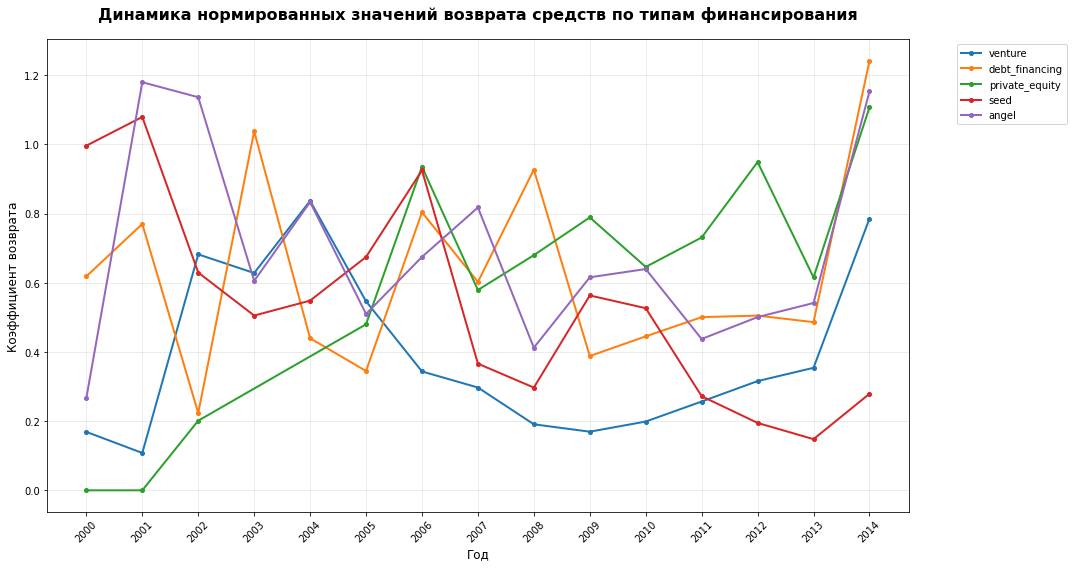

In [124]:
# Строим график с правильным отображением начала данных для каждого типа финансирования
plt.figure(figsize=(15, 8))

# Для каждого типа финансирования строим линию только с тех лет, где есть данные
for fund_type in selected_fund_types:
    fund_data = selected_ratios[fund_type]
    # Находим годы, где есть данные (не NaN)
    years_with_data = fund_data.dropna().index
    values = fund_data[years_with_data]
    
    plt.plot(years_with_data, values, 
             marker='o', 
             linewidth=2, 
             markersize=4, 
             label=fund_type)

plt.title('Динамика нормированных значений возврата средств по типам финансирования', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Коэффициент возврата', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(selected_ratios.index, rotation=45)

plt.tight_layout()
plt.show()

Венчурные инвестиции демонстрируют наиболее устойчивый рост показателя, от 0.17 в 2000 году до 0.79 в 2014 году, что свидетельствует о постепенном улучшении возвратов в этом сегменте. 

Долговое финансирование (debt_financing) показывает высокую, но волатильную эффективность с пиками в 1.24 в 2014 году, что характерно для кредитных инструментов.

Особенно выделяется частное финансирование (private_equity), которое демонстрирует стабильно высокие коэффициенты возврата на уровне 0.6-1.1 в последние годы, что делает его одним из наиболее надежных инструментов. 

seed и angel показывают снижение эффективности в середине периода с последующим восстановлением, причем angel инвестиции в 2014 году достигли рекордного коэффициента 1.15, что может свидетельствовать об улучшении отбора проектов на ранних стадиях.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



Проект по исследованию стартапов включал комплексный анализ данных о венчурных инвестициях за период 2000-2014 годов. Работа выполнялась в несколько этапов:

* Знакомство и предобработка данных: выполнены загрузка, очистка и преобразование данных, включая исправление форматов числовых значений, обработку пропусков, приведение типов данных и устранение дубликатов.

* Инжиниринг признаков: классификация компаний по срокам финансирования и сегментация рынка на массовые, средние и нишевые сегменты.

* Анализ выбросов: выявление аномальных значений финансирования и фильтрация данных для обеспечения репрезентативности анализа.

* Анализ динамики: исследование тенденций финансирования по годам, сегментам рынка и типам инвестиций.

Структура рынка инвестиций

59% стартапов получают финансирование только один раз. Основной объем инвестиций (62%) приходится на компании с длительной историей финансирования (более года). Рынок сегментирован: 49 массовых сегментов охватывают 88% всех компаний, тогда как 289 нишевых направлений распределяют между собой лишь 2% рынка.

Динамика инвестиционной активности

Пик инвестиционной активности пришелся на 2013 год (12 880 раундов). В 2014 году наблюдалось снижение количества раундов на 45%, но стабилизация среднего размера раунда на уровне 560 тыс. долларов. Максимальный типичный размер раунда отмечался в 2005 году (4.5 млн долларов)

Эффективность типов финансирования

Венчурное финансирование - абсолютный лидер по объему привлеченных средств (129 млрд долларов) и популярности (18 818 компаний). Частные инвестиции (private equity) демонстрируют наиболее стабильно высокие коэффициенты возврата (0.6-1.1). Долговое финансирование показывает высокую, но волатильную эффективность. Гранты имеют нулевую доходность, как и должно быть.

Наиболее уверенный рост в 2014 году показали:
- Technology (+67% роста, 202 млн долларов)
- Internet (+69% роста, 118 млн долларов) 
- Medical (+172% роста, 175 млн долларов)

**Рекомендации на 2015 год**

Технологический сектор (Technology) представляет наиболее сбалансированную возможность для инвестиций:
- Высокие темпы роста (67% в 2014 году)
- Значительный объем рынка (202 млн долларов)
- Устойчивую динамику развития
- Диверсифицированную структуру внутри сегмента

Альтернативой может стать медицинский сектор (Medical), демонстрирующий взрывной рост, но требующий более тщательной проверки устойчивости тренда.


Частные инвестиции (private equity) являются наиболее предпочтительным типом финансирования:
- Стабильно высоких коэффициентов возврата (0.6-1.1)
- Меньшей волатильности по сравнению с другими типами
- Возможности участия в зрелых, проверенных проектах
- Диверсификации рисков через портфельный подход

Венчурное финансирование остается основным инструментом рынка, но требует более избирательного подхода к отбору проектов.

Важно! Обратите внимание на неполные данные за 2014 год, это требует осторожности при экстраполяции тенденций на 2015 год. Рекомендуется дополнительный мониторинг рынка для подтверждения выявленных трендов.